In [1]:
import sys
from collections import defaultdict
from itertools import combinations
from pathlib import Path
from statistics import correlation, mean

import litellm
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import kendalltau, rankdata
from sklearn.base import clone
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import LassoCV, LinearRegression, RidgeCV
from sklearn.model_selection import LeaveOneOut
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from tabulate import tabulate
from wordfreq import zipf_frequency
from words import get_words

# Add the repo root to sys.path so we can import our modules
repo_root = Path.cwd().resolve().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from GenerateKeywordCards2.async_rng import AsyncRng  # noqa: E402
from GenerateKeywordCards2.check_familiarity import (  # noqa: E402
    check_familiarity_async,  # noqa: E402
)

# from asyncio import TaskGroup  <-- Doesn't work in Jupyter, use CompatTaskGroup instead.
from GenerateKeywordCards2.compat_task_group import (  # noqa: E402
    CompatTaskGroup as TaskGroup,  # noqa: E402
)
from GenerateKeywordCards2.manual_ratings import (  # noqa: E402
    add_manual_ratings_words,
    get_manual_ratings,
)
from GenerateKeywordCards2.pip_audit_with_urls import pip_audit_with_urls  # noqa: E402
from GenerateKeywordCards2.rate_words import RatingsByWord  # noqa: E402
from GenerateKeywordCards2.rate_words_with_variations import (  # noqa: E402
    ModelParams,
    VariationParams,
    VariationView,
    iter_variation_views,
    rate_words_with_variations,
)

In [2]:
# For some reason, the Ruff: Format Imports command fails with "unspecified reason" if these imports are in the same cell as the other imports.
from GenerateKeywordCards2.rate_words_with_variations import (  # noqa: E402
    combine_results,
    filter_results,
)

In [3]:
litellm.cache = litellm.Cache(type="disk")

def get_cache_count()->int:
    disk_cache_object = litellm.cache.cache.disk_cache
    return len(disk_cache_object)

initial_cache_count = get_cache_count()

# Words

Get a large set of words in descending order of frequency. List examples of words at various positions in the list.

Most words become obscure or strange at around position 20,000 but some very recognizable words remaineven at position 50,000.

In [4]:
all_words = get_words()

step = 5_000
segment_size = 20
indices = list(range(0, len(all_words) - segment_size, step))
if indices[-1] != len(all_words) - segment_size:
    indices.append(len(all_words) - segment_size)
for i in indices:
    segment = all_words[i : i + segment_size]
    frequency = zipf_frequency(segment[0], "en")
    print(f"{i} ({frequency}): {segment}")

0 (7.73): ['the', 'to', 'and', 'of', 'a', 'in', 'i', 'is', 'for', 'that', 'you', 'it', 'on', 'with', 'this', 'was', 'be', 'as', 'are', 'have']
5000 (4.21): ['aims', 'arc', 'backup', 'beaten', 'bitter', 'blown', 'branches', 'campaigns', 'chips', 'cia', 'clever', 'clinic', 'closest', 'collections', 'continuous', 'converted', 'correctly', 'creator', 'creatures', 'criteria']
10000 (3.77): ['chop', 'circuits', 'clifford', 'co2', 'cody', 'coleman', 'commanded', 'commissioners', 'communicating', 'comparative', 'complement', 'connor', 'conquer', 'conquest', 'contested', 'continuity', 'cornwall', 'crawl', 'credible', 'cursed']
15000 (3.5): ['paycheck', 'peaches', 'peaked', 'picturesque', 'pilgrimage', 'pillows', 'pivot', 'pivotal', 'por', 'pressured', 'preventive', 'primer', 'profitability', 'progressing', 'provoke', 'ps3', 'pulmonary', 'punishing', 'rad', 'radicals']
20000 (3.28): ['assay', 'assigning', 'assorted', 'axel', 'badminton', 'barbarian', 'bedrock', 'bihar', 'bj', 'blaine', 'boardwal

# Check familiarity

Are the various models familiar with the game So Clover!?

In [5]:
total_metadata = 0
tasks_by_model_params = {}
small_models = [
    "openai/gpt-5.4-mini-2026-03-17",
    "anthropic/claude-haiku-4-5-20251001",
    "gemini/gemini-3-flash-preview",
    "deepseek/deepseek-v4-flash",
]
async with TaskGroup() as tg:
    for model in small_models:
        tasks_by_model_params[model] = tg.create_task(
            check_familiarity_async(model), eager_start=True
        )

for model, task in tasks_by_model_params.items():
    familiarity, metadata = task.result()
    total_metadata += metadata
    familiarity_str = familiarity.replace("\n", " ")
    print(
        f"{model} ${metadata.total_cost:.4f} {metadata.output_tokens} output tokens: {familiarity_str}"
    )

print(total_metadata)


Provider List: https://docs.litellm.ai/docs/providers

openai/gpt-5.4-mini-2026-03-17 $0.0084 1847 output tokens: Yes — So Clover is a great fit for carefully chosen keywords, because the whole game lives or dies on how *clueable* and *distinctive* the words are.  If you’re making an expansion of keyword cards, the best words are not just “interesting,” but **good clue magnets**: words that can be connected in multiple ways without being too broad, too obscure, or too easily confused with other cards.  ## What qualities to look for in keywords  ### 1. **They should support multiple clue paths** The best words can be hinted at from several angles: - meaning - category - function - appearance - sound/wordplay - common associations - opposite/contrast  Example: **“Bridge”** can be clued via: - architecture - cards - over water - connecting two things - “crossing”  That flexibility helps players build a clue that hits two cards at once.  ---  ### 2. **They should be familiar, but not too 

# Sample Rating Words

Select a representative set of words in a variety of ways to measure how well they will work as So Clover! keywords.

In [6]:
# Initially, rate a small number of words with all small models.
initial_number_of_words = 3000

# Include the base game's words
existing_keywords_file = (
    repo_root / "GenerateKeywordCards" / "CloverExistingKeywords.csv"
)
existing_keywords = existing_keywords_file.read_text(encoding="utf-8-sig").splitlines()
existing_keywords = [w.lower() for w in existing_keywords]
assert len(existing_keywords) <= initial_number_of_words

# Sample remaining words from all_words
existing_keywords_set = set(existing_keywords)
all_words_without_existing = [w for w in all_words if w not in existing_keywords_set]
local_rng = AsyncRng(123).unwrap()
sampled_keywords = local_rng.sample(
    all_words_without_existing, k=initial_number_of_words - len(existing_keywords)
)

print(
    f"Selected {len(existing_keywords)} existing keywords and {len(sampled_keywords)} new keywords with all small models."
)
initial_words = existing_keywords + sampled_keywords

Selected 880 existing keywords and 2120 new keywords with all small models.


# Calculate Ratings

In [7]:
models_params = [
    ModelParams(
        model="openai/gpt-5.4-mini-2026-03-17",
        reasoning_effort="none",
        batch_size_overall=300,
        batch_size_aspects=100,
    ),
    ModelParams(
        model="anthropic/claude-haiku-4-5-20251001",
        reasoning_effort="low",
        batch_size_overall=300,
        batch_size_aspects=50,
    ),
    ModelParams(
        model="gemini/gemini-3-flash-preview",
        reasoning_effort="none",
        batch_size_overall=300,
        batch_size_aspects=50,
    ),
    ModelParams(
        model="gemini/gemini-3.5-flash",
        reasoning_effort="none",
        batch_size_overall=300,
        batch_size_aspects=50,
    ),
    # ModelParams(
    #     model="gemini/gemini-3.1-pro-preview",
    #     reasoning_effort="none",
    #     batch_size_overall=300,
    #     batch_size_aspects=100,
    # ),
    ModelParams(
        model="deepseek/deepseek-v4-flash",
        reasoning_effort="none",
        batch_size_overall=300,
        batch_size_aspects=100,
    ),
    ModelParams(
        model="deepseek/deepseek-v4-pro",
        reasoning_effort="none",
        batch_size_overall=300,
        batch_size_aspects=100,
    ),
]

prompt_names = [
    "simple",
    "gameplay",
    "associations",
    "aspects_detailed",
]
results_by_variation_before_combining = await rate_words_with_variations(
    models_params, prompt_names, initial_words
)

* Rating openai/gpt-5.4-mini-2026-03-17 none 300 100 simple...
> openai/gpt-5.4-mini-2026-03-17 simple none: 300 words [ike...]
< openai/gpt-5.4-mini-2026-03-17 simple none: 300 words [ike...]
> openai/gpt-5.4-mini-2026-03-17 simple none: 300 words [commissary...]
< openai/gpt-5.4-mini-2026-03-17 simple none: 300 words [commissary...]
> openai/gpt-5.4-mini-2026-03-17 simple none: 300 words [jocks...]
< openai/gpt-5.4-mini-2026-03-17 simple none: 300 words [jocks...]
> openai/gpt-5.4-mini-2026-03-17 simple none: 300 words [plush...]
< openai/gpt-5.4-mini-2026-03-17 simple none: 300 words [plush...]
> openai/gpt-5.4-mini-2026-03-17 simple none: 300 words [sneak...]
< openai/gpt-5.4-mini-2026-03-17 simple none: 300 words [sneak...]
> openai/gpt-5.4-mini-2026-03-17 simple none: 300 words [seneca...]
< openai/gpt-5.4-mini-2026-03-17 simple none: 300 words [seneca...]
> openai/gpt-5.4-mini-2026-03-17 simple none: 300 words [bus...]
< openai/gpt-5.4-mini-2026-03-17 simple none: 300 words [bus

# Cost

In [8]:
print("Variation cost:")

total_metadata = 0
for variation in sorted(results_by_variation_before_combining.keys()):
    variation_result = results_by_variation_before_combining[variation]
    total_metadata += variation_result.metadata
    print(variation)
    print(
        f"  ${variation_result.metadata.total_cost:.4f} {variation_result.metadata.output_tokens:,} output tokens {variation_result.metadata.reasoning_tokens:,} reasoning tokens",
        flush=True,
    )

print(total_metadata)

Variation cost:
anthropic/claude-haiku-4-5-20251001 low 300 50 aspects_detailed
  $3.7985 730,960 output tokens 126,695 reasoning tokens
anthropic/claude-haiku-4-5-20251001 low 300 50 associations
  $0.5929 113,867 output tokens 58,808 reasoning tokens
anthropic/claude-haiku-4-5-20251001 low 300 50 gameplay
  $0.5478 104,522 output tokens 45,762 reasoning tokens
anthropic/claude-haiku-4-5-20251001 low 300 50 simple
  $0.4649 88,485 output tokens 29,560 reasoning tokens
deepseek/deepseek-v4-flash none 300 100 aspects_detailed
  $0.1570 538,081 output tokens 76,760 reasoning tokens
deepseek/deepseek-v4-flash none 300 100 associations
  $0.0172 54,313 output tokens 12,801 reasoning tokens
deepseek/deepseek-v4-flash none 300 100 gameplay
  $0.0172 54,034 output tokens 11,910 reasoning tokens
deepseek/deepseek-v4-flash none 300 100 simple
  $0.0176 56,185 output tokens 14,973 reasoning tokens
deepseek/deepseek-v4-pro none 300 100 aspects_detailed
  $0.8161 915,598 output tokens 457,504 reas

# Add Combined Results

In [9]:
combined_all_results = combine_results(
    iter_variation_views(results_by_variation_before_combining)
)

def get_combined_params(name: str):
    return VariationParams(
        model_params=ModelParams(
            model="z combined",
            reasoning_effort="default",
            batch_size_overall=0,
            batch_size_aspects=0,
        ),
        prompt_name=name,
    )

selected_names = [
    "gemini-3-flash-preview associations",
    "gemini-3-flash-preview gameplay",
    "gemini-3-flash-preview simple",
    "deepseek-v4-flash associations",
    "deepseek-v4-flash gameplay",
    "deepseek-v4-flash simple",
    "gpt-5.4-mini associations",
]
combined_selected_results = combine_results(
    filter_results(
        iter_variation_views(results_by_variation_before_combining), selected_names
    )
)

combined_results_by_variation = {
    get_combined_params("all"): combined_all_results,
    get_combined_params("selected"): combined_selected_results,
}

print("Combined variations:")
for variation in combined_results_by_variation.keys():
    print(variation.short_str())

results_by_variation = results_by_variation_before_combining.copy()
results_by_variation.update(combined_results_by_variation)

Combined variations:
z combined all
z combined selected


# Examples

In [10]:
for variation_view in iter_variation_views(results_by_variation):
    variation_result = variation_view.variation_result
    print(variation_view.short_str())

    sorted_by_ratings = sorted(
        initial_words,
        key=lambda w: variation_view.overall_rating(w),
        reverse=True,
    )
    number_of_examples = 10
    print(f"  best: {sorted_by_ratings[:number_of_examples]}")
    print(f"  worst: {sorted_by_ratings[-number_of_examples:]}")
    average_rating_existing_keywords = mean(
        variation_view.overall_rating(w) for w in existing_keywords
    )
    average_rating_new_keywords = mean(
        variation_view.overall_rating(w) for w in sampled_keywords
    )

claude-haiku-4-5 aspects_detailed [assoc]
  best: ['apple', 'country', 'dress', 'edge', 'heart', 'house', 'ice', 'iron', 'letter', 'life']
  worst: ['mirren', 'straus', 'ormond', 'garcia', 'maura', 'hildebrand', 'shay', 'cts', 'ppt', 'uab']
claude-haiku-4-5 aspects_detailed [gamepl]
  best: ['heart', 'mountain', 'hearts', 'adventure', 'angel', 'apple', 'baby', 'bar', 'base', 'beach']
  worst: ['hutchins', 'tk', 'straus', 'ormond', 'maura', 'hildebrand', 'shay', 'cts', 'ppt', 'uab']
claude-haiku-4-5 associations
  best: ['mind', 'air', 'angel', 'axe', 'bark', 'base', 'bear', 'black', 'blood', 'blue']
  worst: ['nasa', 'glover', 'garcia', 'maura', 'hildebrand', 'fred', 'cts', 'ppt', 'uab', '8']
claude-haiku-4-5 gameplay
  best: ['apple', 'arm', 'baby', 'bear', 'blue', 'body', 'box', 'car', 'court', 'dance']
  worst: ['ormond', 'maura', 'hildebrand', 'fred', 'cts', 'orthogonal', 'ppt', 'uab', '8', 'macbook']
claude-haiku-4-5 simple
  best: ['clean', 'club', 'dream', 'earth', 'eye', 'famil

# Compare existing Clover game words to random words 

In [11]:
def get_percentage_of_existing_rated_higher_than_sampled(
    variation_view: VariationView,
) -> float:
    count_existing_higher = 0
    for w_existing in existing_keywords:
        rating_existing = variation_view.overall_rating(w_existing)
        for w_sampled in sampled_keywords:
            rating_new = variation_view.overall_rating(w_sampled)
            if rating_existing > rating_new:
                count_existing_higher += 1
    total_comparisons = len(existing_keywords) * len(sampled_keywords)
    if total_comparisons == 0:
        return 0.0
    percentage = (count_existing_higher / total_comparisons) * 100
    return percentage


print(
    "Percentage of comparisons where existing keywords are rated higher than new keywords:"
)
rows = []
for variation_view in iter_variation_views(results_by_variation):
    percentage = get_percentage_of_existing_rated_higher_than_sampled(variation_view)
    rows.append([variation_view.short_str(), percentage])
rows.sort(key=lambda r: r[1], reverse=True) # sort by percentage, highest first
print(tabulate(rows, headers=["Variation", "Percentage"], tablefmt="github", floatfmt=".1f"))

Percentage of comparisons where existing keywords are rated higher than new keywords:
| Variation                                        |   Percentage |
|--------------------------------------------------|--------------|
| z combined all                                   |         96.4 |
| z combined selected                              |         96.4 |
| gemini-3.5-flash associations                    |         93.8 |
| gemini-3-flash-preview associations              |         92.8 |
| deepseek-v4-flash gameplay                       |         92.0 |
| gemini-3-flash-preview gameplay                  |         91.6 |
| gemini-3.5-flash gameplay                        |         91.5 |
| gemini-3.5-flash simple                          |         91.2 |
| gemini-3-flash-preview simple                    |         90.7 |
| gemini-3-flash-preview aspects_detailed [assoc]  |         89.9 |
| deepseek-v4-flash simple                         |         89.9 |
| deepseek-v4-flash associatio

In [12]:
print("Average ratings:")
for variation_view in iter_variation_views(results_by_variation):
    variation_result = variation_view.variation_result
    print(
        f"{variation_view.short_str()}: existing keywords={average_rating_existing_keywords:.1f}, new keywords={average_rating_new_keywords:.1f}"
    )

Average ratings:
claude-haiku-4-5 aspects_detailed [assoc]: existing keywords=7.6, new keywords=4.2
claude-haiku-4-5 aspects_detailed [gamepl]: existing keywords=7.6, new keywords=4.2
claude-haiku-4-5 associations: existing keywords=7.6, new keywords=4.2
claude-haiku-4-5 gameplay: existing keywords=7.6, new keywords=4.2
claude-haiku-4-5 simple: existing keywords=7.6, new keywords=4.2
deepseek-v4-flash aspects_detailed [assoc]: existing keywords=7.6, new keywords=4.2
deepseek-v4-flash aspects_detailed [gamepl]: existing keywords=7.6, new keywords=4.2
deepseek-v4-flash associations: existing keywords=7.6, new keywords=4.2
deepseek-v4-flash gameplay: existing keywords=7.6, new keywords=4.2
deepseek-v4-flash simple: existing keywords=7.6, new keywords=4.2
deepseek-v4-pro aspects_detailed [assoc]: existing keywords=7.6, new keywords=4.2
deepseek-v4-pro aspects_detailed [gamepl]: existing keywords=7.6, new keywords=4.2
deepseek-v4-pro associations: existing keywords=7.6, new keywords=4.2
dee

Histograms of ratings for new and existing keywords, for each model and variation:


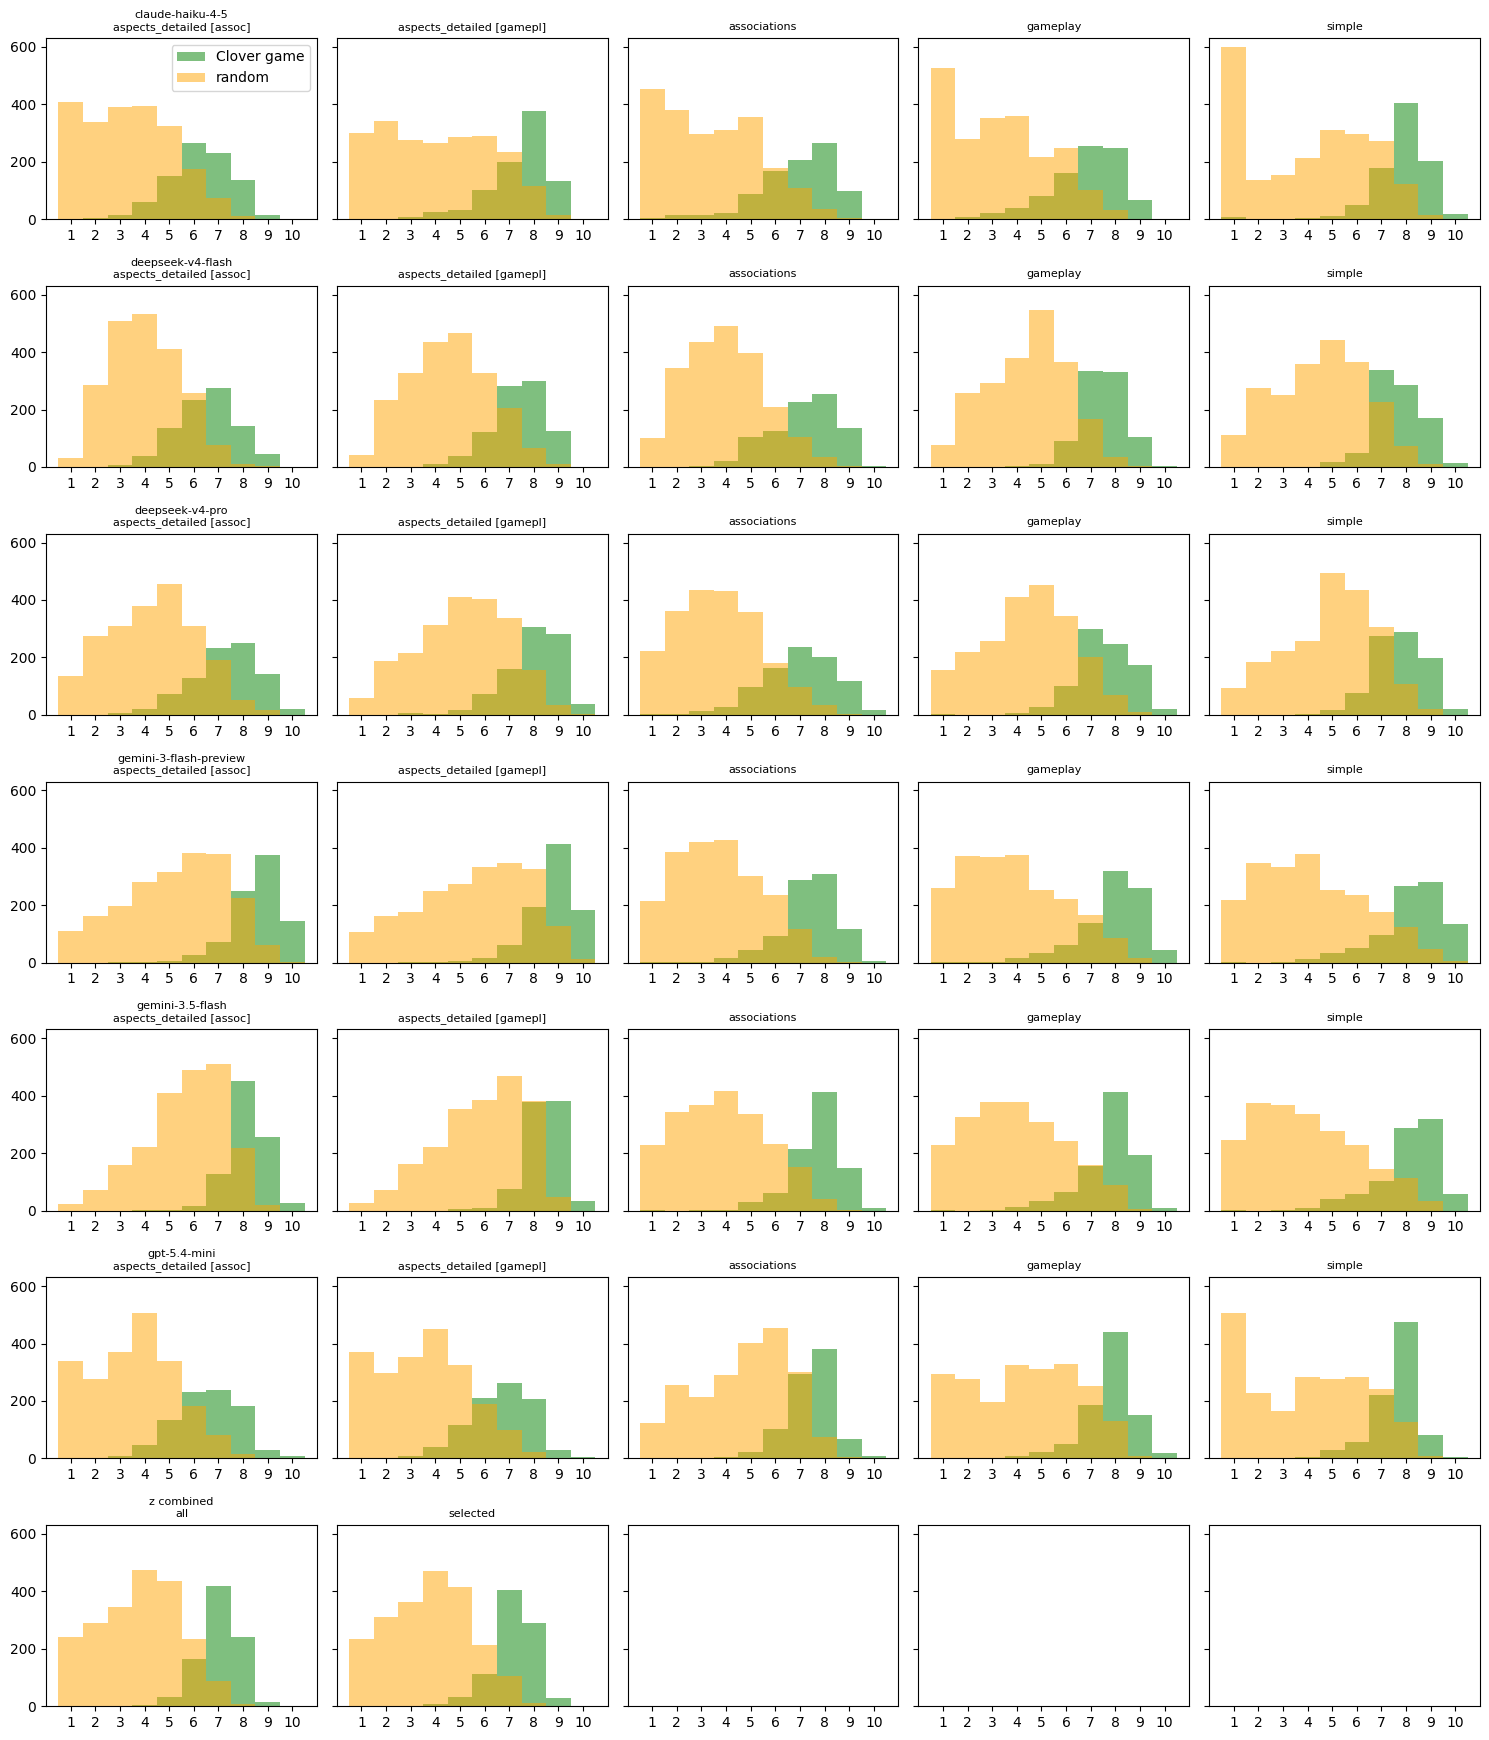

In [13]:
print(
    "Histograms of ratings for new and existing keywords, for each model and variation:"
)

variations_per_row = 5
variation_view_count = len(list(iter_variation_views(results_by_variation)))
# Each row will have `variations_per_row` variations, except for the combined results at the end, which may not fit evenly into the rows.
assert (variation_view_count - len(combined_results_by_variation)) % variations_per_row == 0
nrows = (variation_view_count - 1) // variations_per_row + 1
fig, axes = plt.subplots(
    nrows=nrows,
    ncols=variations_per_row,
    figsize=(15, 2.5 * nrows),
    sharex=True,
    sharey=True,
    squeeze=False,
)
for i_variation, variation_view in enumerate(
    iter_variation_views(results_by_variation)
):
    ratings_existing_keywords = [
        variation_view.overall_rating(w) for w in existing_keywords
    ]
    ratings_new_keywords = [
        variation_view.overall_rating(w) for w in sampled_keywords
    ]
    i_column = i_variation % variations_per_row
    i_row = i_variation // variations_per_row
    ax = axes[i_row, i_column]
    ax.hist(ratings_existing_keywords, bins=range(1, 12), alpha=0.5, label="Clover game", color="green")
    ax.hist(ratings_new_keywords, bins=range(1, 12), alpha=0.5, label="random", color="orange")
    ax.set_xticks([x + 0.5 for x in range(1, 11)], labels=range(1, 11))
    ax.tick_params(axis="x", labelbottom=True)
    model_str = variation_view.variation_params.model_params.short_str()
    title_model = model_str if i_column == 0 else ""
    title_prompt = variation_view.short_str().replace(f"{model_str} ", "")
    title = f"{title_model}\n{title_prompt}"
    ax.set_title(title, fontsize=8)
    if i_column == 0 and i_row == 0:
        ax.legend()

fig.tight_layout()
plt.show()

# Correlation between LLM models

In [14]:
print(
    "Kendall rank correlation between ratings of each model/variation with each other model/variation:\n"
)

rows = []
for iA, variation_view_A in enumerate(iter_variation_views(results_by_variation)):
    row = [variation_view_A.short_str()]
    for iB, variation_view_B in enumerate(iter_variation_views(results_by_variation)):
        if iA == iB:
            row.append("")
            continue

        ratings_A_list = [variation_view_A.overall_rating(w) for w in initial_words]
        ratings_B_list = [variation_view_B.overall_rating(w) for w in initial_words]
        # Use kendall_tau correlation because we are more concerned with the relative ranking of words than the absolute rating values.
        # kendall_tau is more robust to different rating scales and non-linear relationships.
        # correlation_value = correlation(ratings_A_list, ratings_B_list)
        kendall_tau_value = kendalltau(ratings_A_list, ratings_B_list)
        row.append(kendall_tau_value.correlation)
    rows.append(row)

header = [""] + [
    variation_view.short_str()
    for variation_view in iter_variation_views(results_by_variation)
]
print(tabulate(rows, headers=header, tablefmt="github", floatfmt=".2f"))

Kendall rank correlation between ratings of each model/variation with each other model/variation:

|                                                  |   claude-haiku-4-5 aspects_detailed [assoc] |   claude-haiku-4-5 aspects_detailed [gamepl] |   claude-haiku-4-5 associations |   claude-haiku-4-5 gameplay |   claude-haiku-4-5 simple |   deepseek-v4-flash aspects_detailed [assoc] |   deepseek-v4-flash aspects_detailed [gamepl] |   deepseek-v4-flash associations |   deepseek-v4-flash gameplay |   deepseek-v4-flash simple |   deepseek-v4-pro aspects_detailed [assoc] |   deepseek-v4-pro aspects_detailed [gamepl] |   deepseek-v4-pro associations |   deepseek-v4-pro gameplay |   deepseek-v4-pro simple |   gemini-3-flash-preview aspects_detailed [assoc] |   gemini-3-flash-preview aspects_detailed [gamepl] |   gemini-3-flash-preview associations |   gemini-3-flash-preview gameplay |   gemini-3-flash-preview simple |   gemini-3.5-flash aspects_detailed [assoc] |   gemini-3.5-flash aspects_detai

# Establish Manual Ratings

Manually rate words for which there is disagreement of the LLMs.

In [15]:
percentile_ranks_by_variation = {}
for variation_view in iter_variation_views(results_by_variation_before_combining):
    ratings = [variation_view.overall_rating(w) for w in initial_words]
    ranks = rankdata(ratings, method="average")
    percentiles = [(r - 1) / (len(ranks) - 1) * 100 for r in ranks]
    percentile_ranks_by_variation[variation_view.get_hash_key()] = dict(zip(initial_words, percentiles))

mean_pairwise_percentile_difference_by_word = {}
for word in initial_words:
    percentiles = [
        percentile_ranks_by_variation[variation_view.get_hash_key()][word]
        for variation_view in iter_variation_views(
            results_by_variation_before_combining
        )
    ]
    pair_differences = [abs(a - b) for a, b in combinations(percentiles, 2)]
    mean_pairwise_percentile_difference_by_word[word] = mean(pair_differences)

initial_words_sorted_by_consistency = sorted(
    initial_words, key=lambda w: mean_pairwise_percentile_difference_by_word[w]
)


def tabulate_difference_details(words: list[str]):
    mean_percentile_by_word = {}
    for word in words:
        mean_percentile_by_word[word] = mean(
            [
                percentile_ranks_by_variation[variation_view.get_hash_key()][word]
                for variation_view in iter_variation_views(results_by_variation_before_combining)
            ]
        )

    # Sort words by mean percentile, from highest to lowest.
    # This makes it easier to read the table to interpret high/low quality words next to one another.
    sorted_words = sorted(words, key=lambda w: mean_percentile_by_word[w], reverse=True)

    header = ["Variation"] + sorted_words
    rows = []

    rows.append(
        ["Mean Rating"] + [mean_percentile_by_word[word] for word in sorted_words]
    )

    rows.append(
        ["Mean Difference"]
        + [mean_pairwise_percentile_difference_by_word[word] for word in sorted_words]
    )

    for variation_view in iter_variation_views(results_by_variation_before_combining):
        row = [variation_view.short_str()]
        for word in sorted_words:
            percentile = percentile_ranks_by_variation[variation_view.get_hash_key()][word]
            row.append(percentile)
        rows.append(row)

    print(tabulate(rows, headers=header, tablefmt="github", floatfmt=".1f"))


number_of_consitency_examples = 25
print("Least consistent words:")
tabulate_difference_details(
    initial_words_sorted_by_consistency[-number_of_consitency_examples:]
)
print("\nMost consistent words:")
tabulate_difference_details(
    initial_words_sorted_by_consistency[:number_of_consitency_examples]
)

# Enable this to update the manual ratings with the leeast consistent words.
# Do this when the set of models/prompts have been updated and are willing to make additional manual ratings.
should_add_manual_ratings = False
if should_add_manual_ratings:
    number_of_manual_ratings = 50
    add_manual_ratings_words(
        initial_words_sorted_by_consistency[-number_of_manual_ratings:]
    )

Least consistent words:
| Variation                                        |   france |   africa |   sherlock |   hello |   small |   niagara |   bookcase |   group |   new |   john |   ymca |   cocaine |   thinks |   simba |   jfk |   ronaldo |   waldo |   put |   gogh |   armstrong |   around |   who |   star's |    8 |   by |
|--------------------------------------------------|----------|----------|------------|---------|---------|-----------|------------|---------|-------|--------|--------|-----------|----------|---------|-------|-----------|---------|-------|--------|-------------|----------|-------|----------|------|------|
| Mean Rating                                      |     71.6 |     71.1 |       64.8 |    62.3 |    61.5 |      60.3 |       60.2 |    60.2 |  58.7 |   55.2 |   51.0 |      50.0 |     49.6 |    48.6 |  48.4 |      46.6 |    45.0 |  44.1 |   43.7 |        43.1 |     40.8 |  37.3 |     36.2 | 31.3 | 24.0 |
| Mean Difference                                  |   

# Use Manual Ratings to Evaluate Overall LLM Ratings

In [16]:
manual_ratings = get_manual_ratings()
manual_ratings_words = sorted(manual_ratings.keys())

# Rating fields should be the same for all words
# Note that here we're depending on the order of fields used by get_manual_ratings().
rating_fields = list(manual_ratings[manual_ratings_words[0]].keys())
for word in manual_ratings_words:
    assert list(manual_ratings[word].keys()) == rating_fields

print("Kendall rank correlation between manual ratings and model ratings:")
rows = []
fields_to_display = ["Association Overall", "Gameplay Overall"]
for variation_view in iter_variation_views(results_by_variation):
    row = []
    for field in fields_to_display:
        manual_ratings_for_field = [manual_ratings[w][field] for w in manual_ratings_words]
        model_ratings_for_field = [
            variation_view.overall_rating(w) for w in manual_ratings_words
        ]
        if row == []:
            row.append(variation_view.short_str())
        tau = kendalltau(manual_ratings_for_field, model_ratings_for_field).statistic
        row.append(tau)
    rows.append(row)

rows.sort(key=lambda r: r[1], reverse=True) # sort by association overall, least difference first

print(
    tabulate(
        rows,
        headers=["Variation"] + fields_to_display,
        tablefmt="github",
        floatfmt=".2f",
    )
)

Kendall rank correlation between manual ratings and model ratings:
| Variation                                        |   Association Overall |   Gameplay Overall |
|--------------------------------------------------|-----------------------|--------------------|
| deepseek-v4-flash associations                   |                  0.44 |               0.40 |
| z combined all                                   |                  0.41 |               0.43 |
| deepseek-v4-pro aspects_detailed [assoc]         |                  0.39 |               0.38 |
| gpt-5.4-mini associations                        |                  0.37 |               0.35 |
| deepseek-v4-flash simple                         |                  0.35 |               0.31 |
| z combined selected                              |                  0.34 |               0.37 |
| gpt-5.4-mini aspects_detailed [assoc]            |                  0.33 |               0.34 |
| gpt-5.4-mini simple                              

In [17]:
greedy_names = []
greedy_tau = -1.0
greedy_results = None
while True:
    next_tau_by_variation = {}
    for variation_view in iter_variation_views(results_by_variation_before_combining):
        manual_ratings_list = [manual_ratings[w]["Association Overall"] for w in manual_ratings_words]
        greedy_results = combine_results(filter_results(iter_variation_views(results_by_variation_before_combining), greedy_names + [variation_view.short_str()]))
        combined_ratings_list = [
            greedy_results.ratings_by_word[w]["overall"] for w in manual_ratings_words
        ]
        tau = kendalltau(manual_ratings_list, combined_ratings_list).statistic
        next_tau_by_variation[variation_view.short_str()] = tau

    best_next_variation, best_next_tau = max(
        next_tau_by_variation.items(), key=lambda item: item[1]
    )
    if best_next_tau > greedy_tau:
        greedy_names.append(best_next_variation)
        greedy_tau = best_next_tau
        print(f"Added {best_next_variation} -> tau={best_next_tau:.3f}")
    else:
        print(f"Done. Stopped before adding {best_next_variation} -> tau={best_next_tau:.3f}.")
        break

assert greedy_results is not None
greedy_combined_params = get_combined_params("greedy")
combined_results_by_variation[greedy_combined_params] = greedy_results
results_by_variation = results_by_variation_before_combining.copy()
results_by_variation.update(combined_results_by_variation)
print(f"Added {greedy_combined_params.short_str()} to results_by_variation.")

Added deepseek-v4-flash associations -> tau=0.436
Added deepseek-v4-pro aspects_detailed [assoc] -> tau=0.512
Added gpt-5.4-mini aspects_detailed [assoc] -> tau=0.540
Added deepseek-v4-flash simple -> tau=0.552
Done. Stopped before adding deepseek-v4-flash associations -> tau=0.552.
Added z combined greedy to results_by_variation.


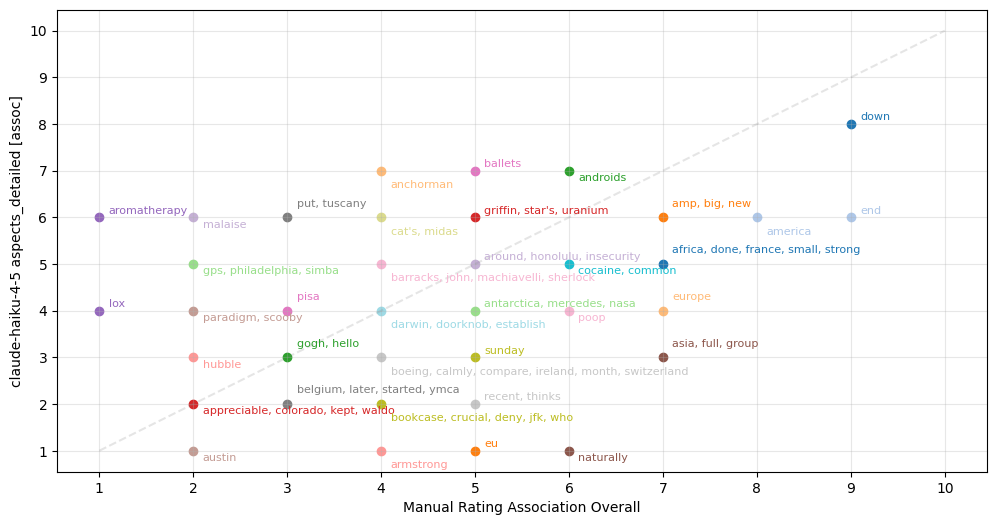

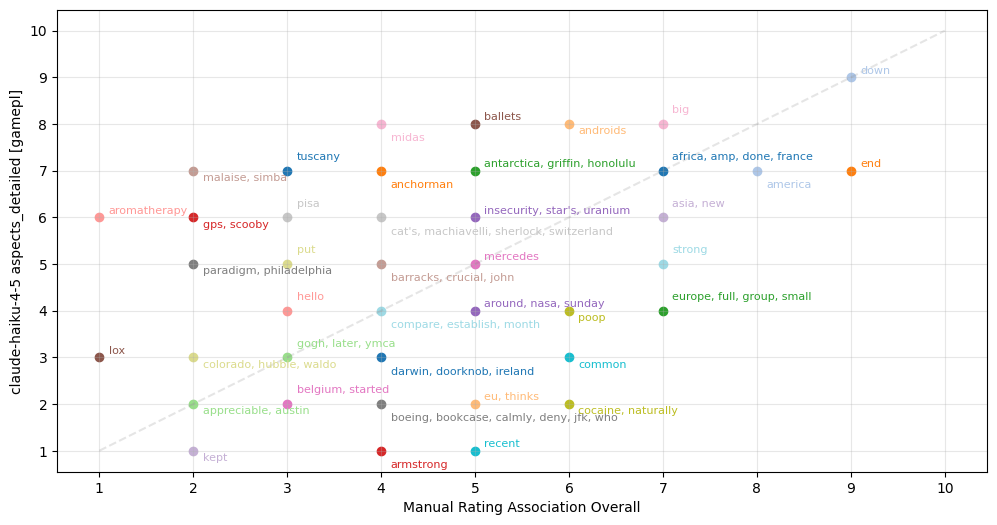

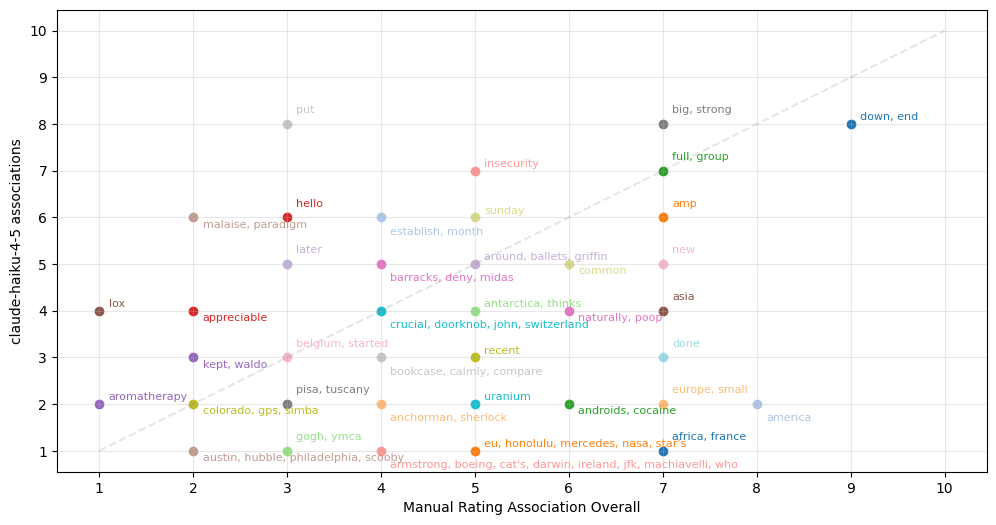

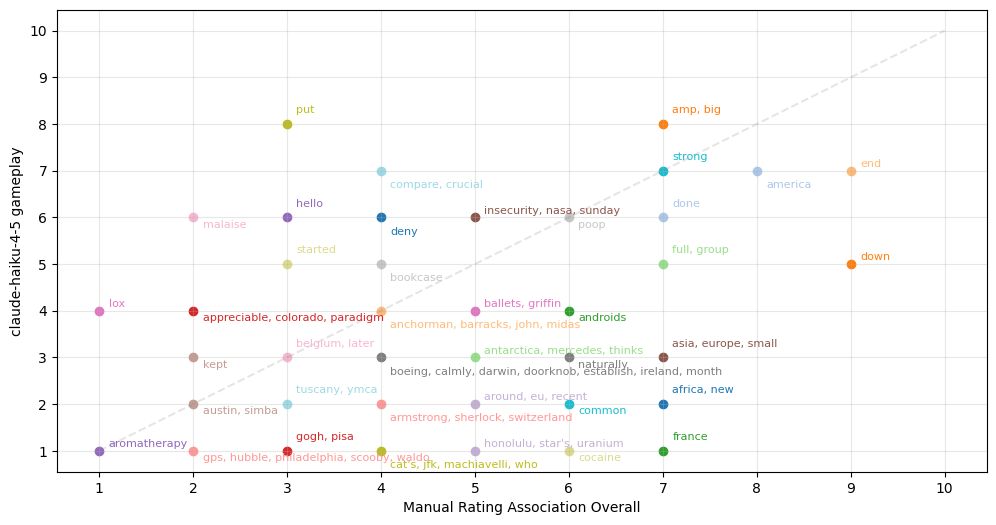

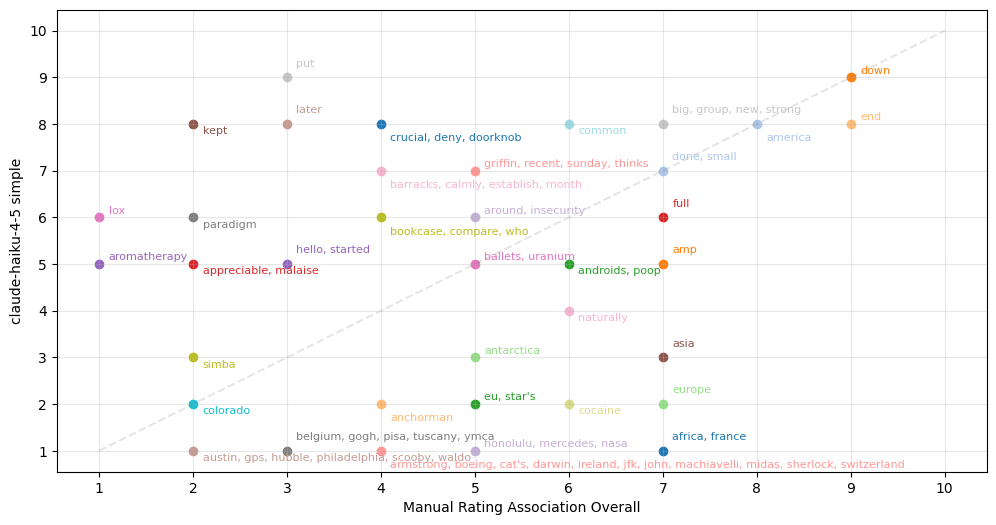

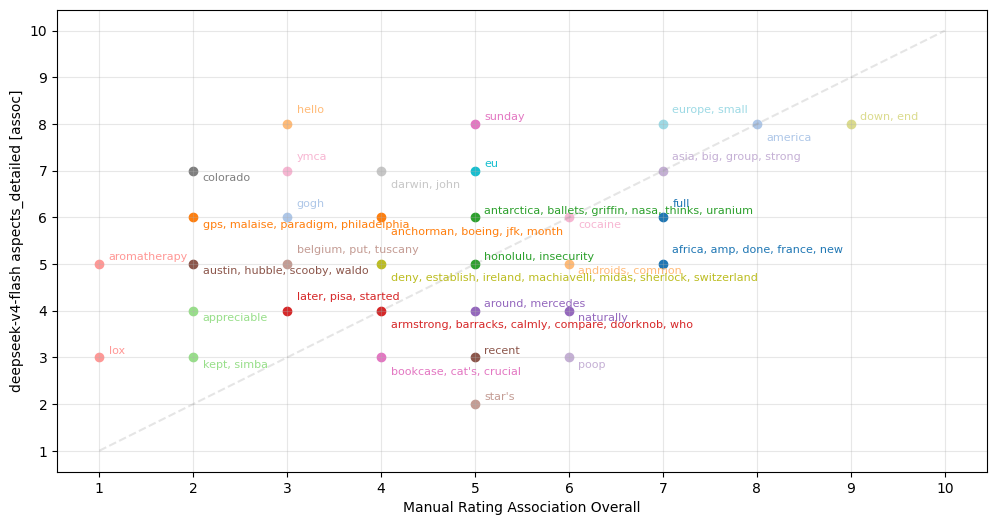

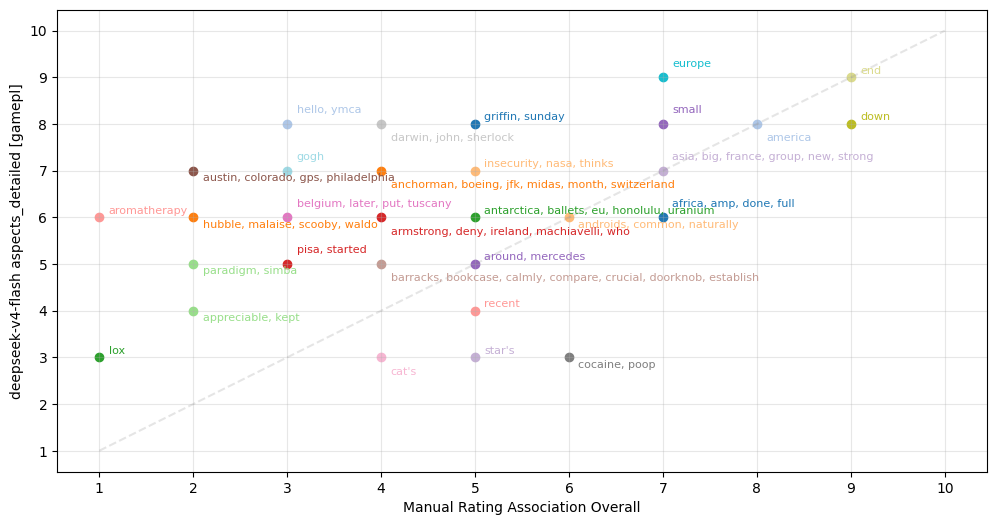

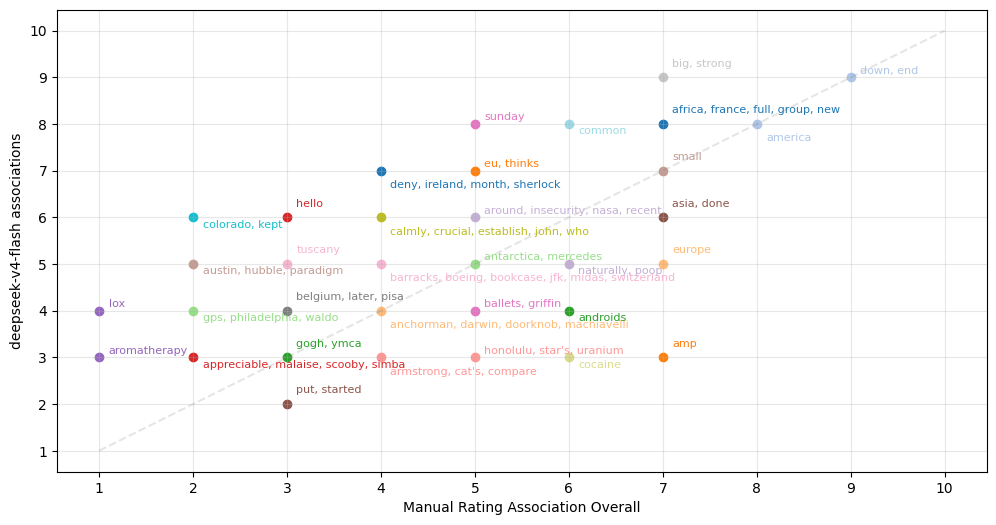

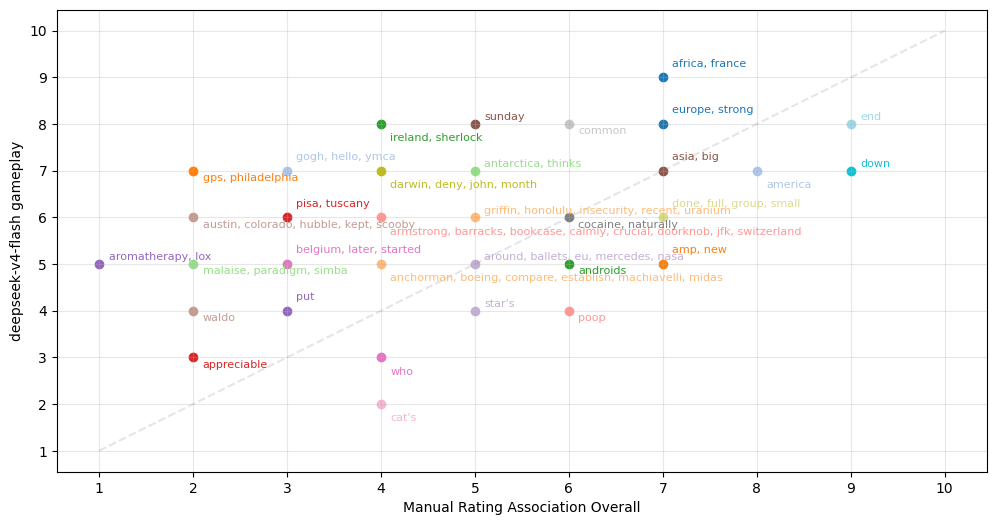

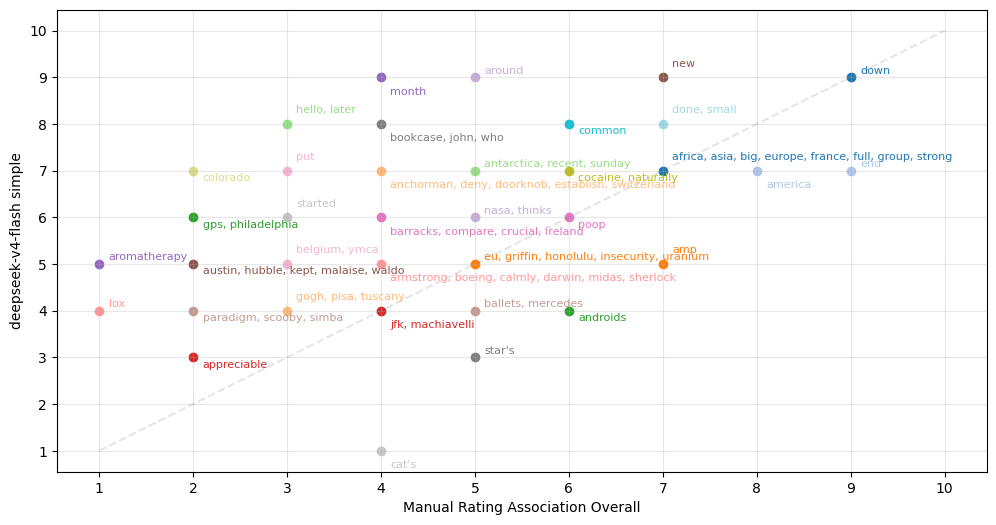

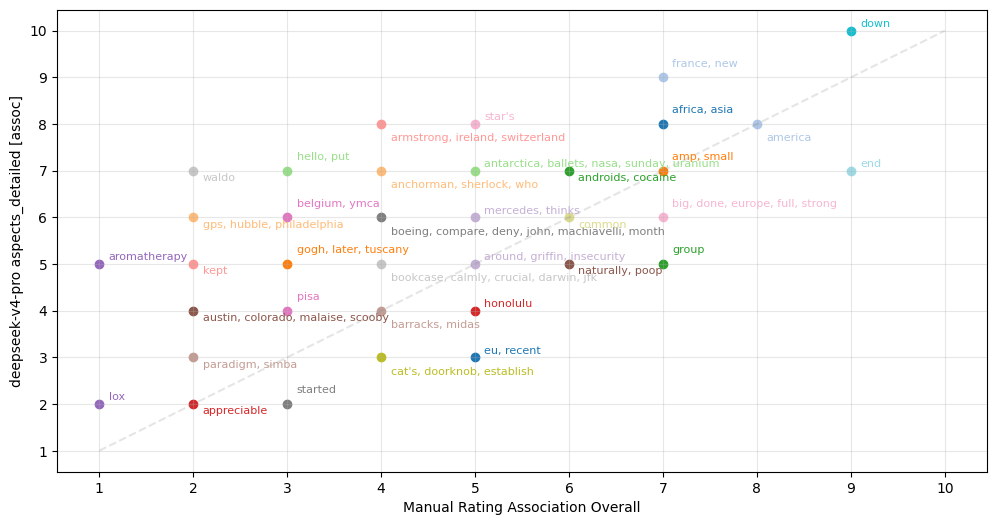

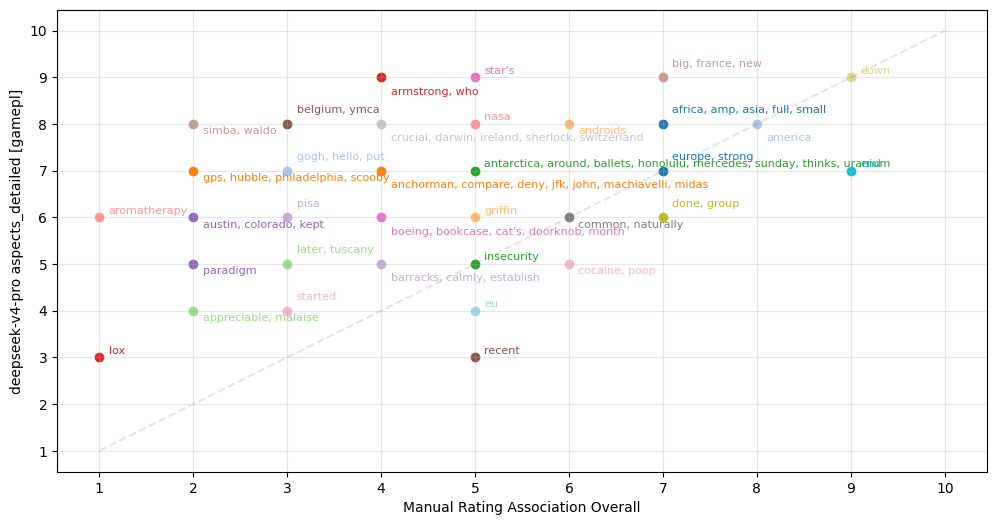

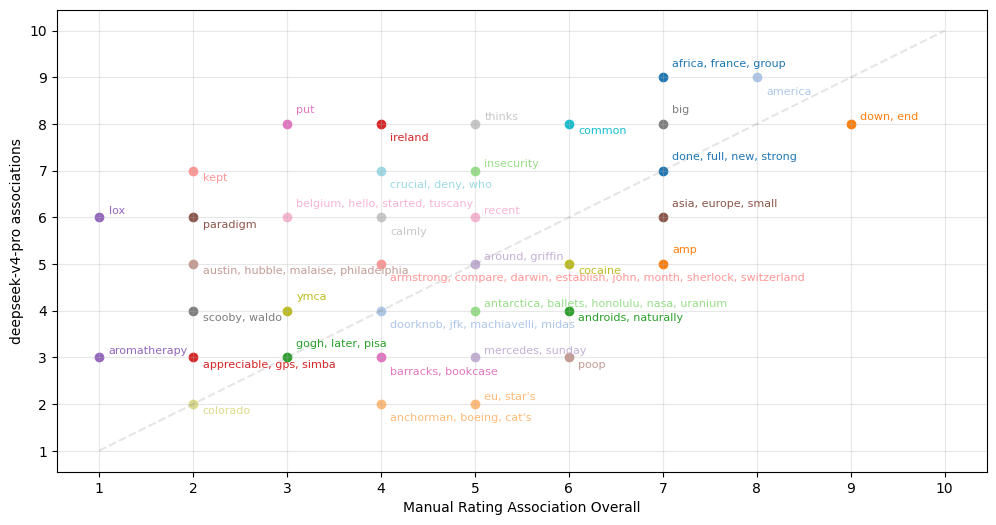

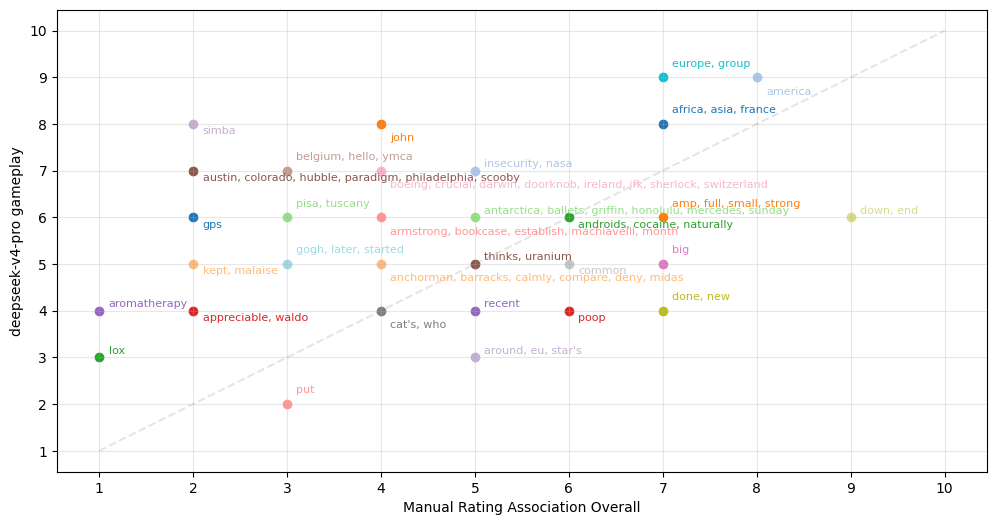

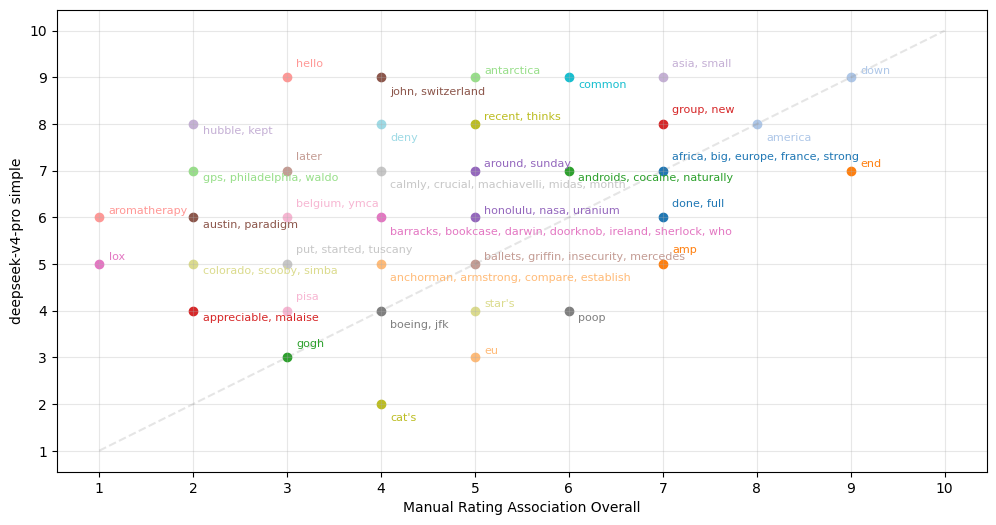

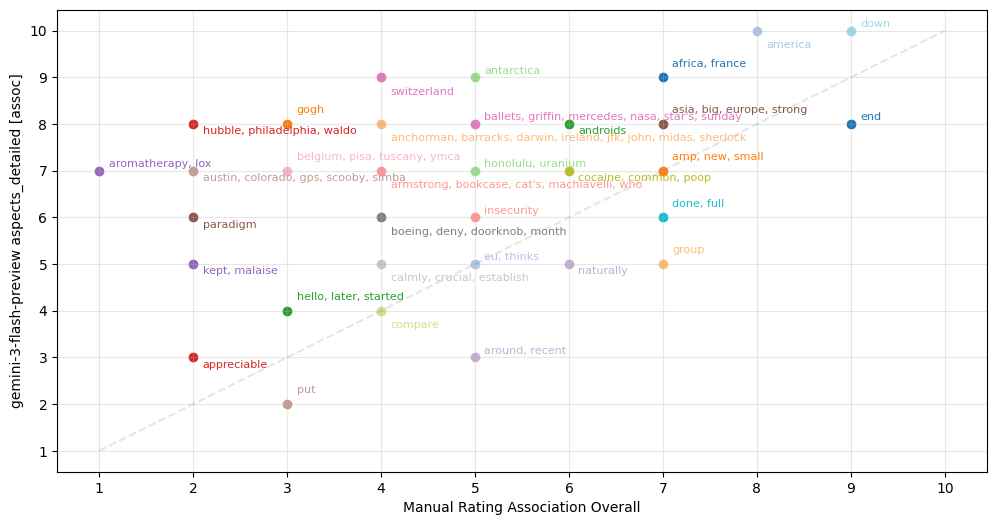

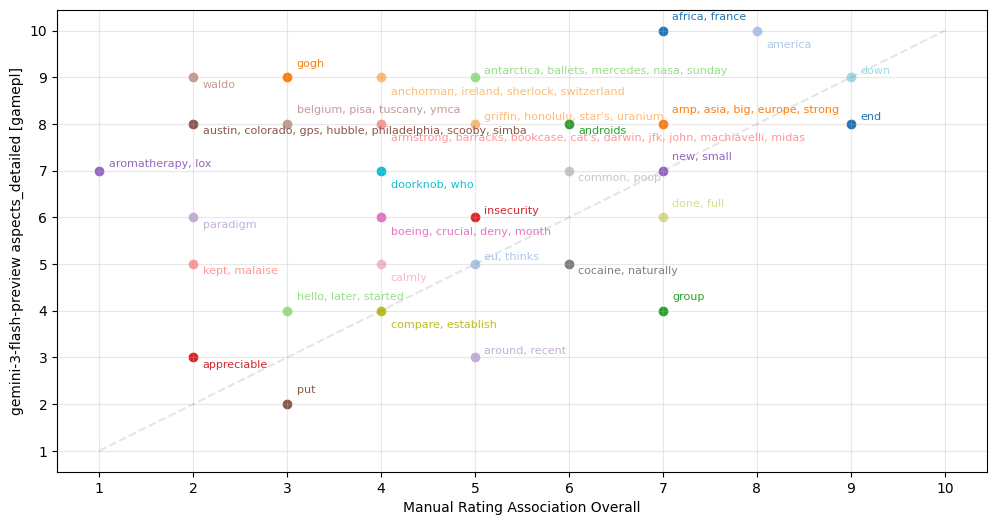

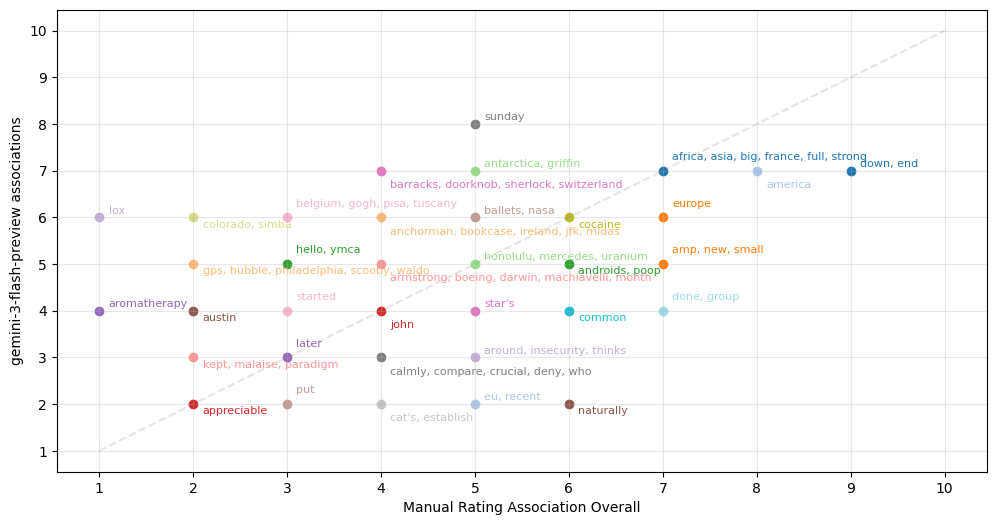

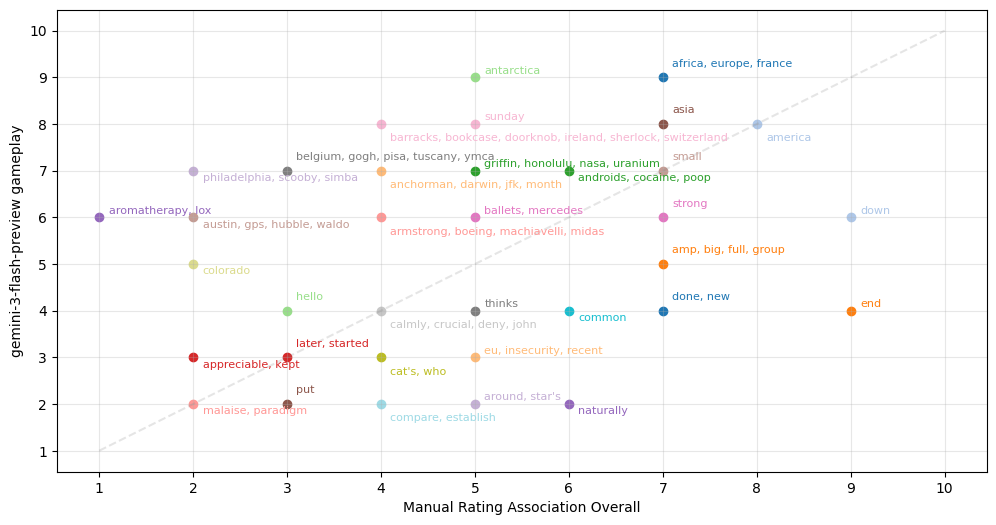

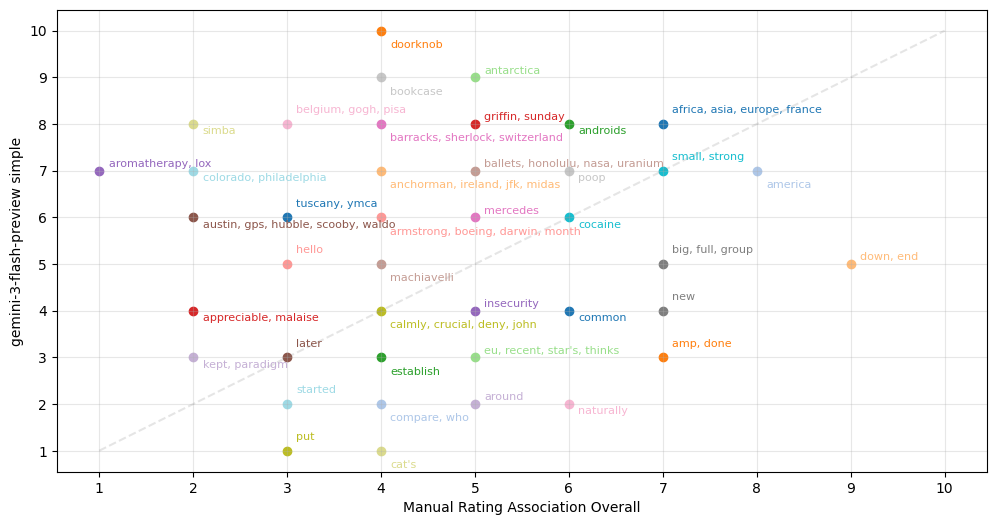

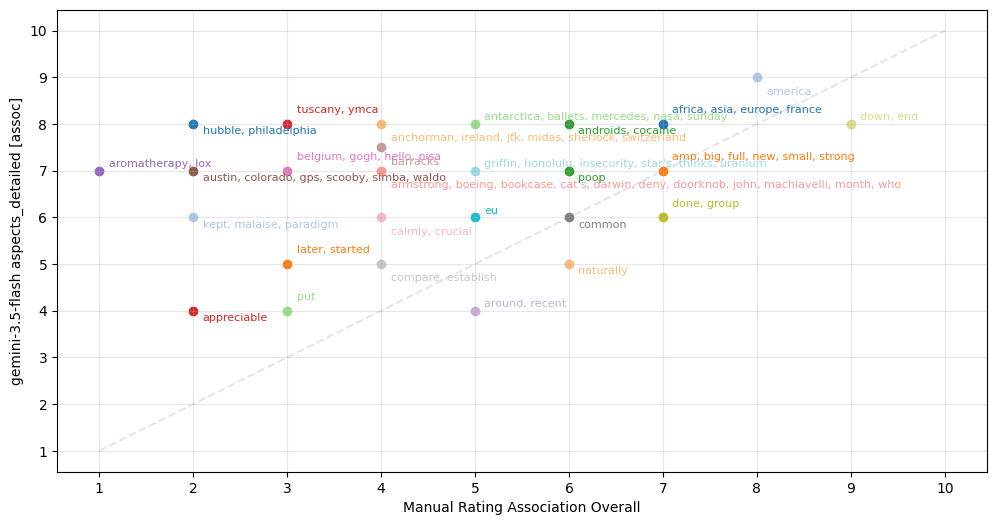

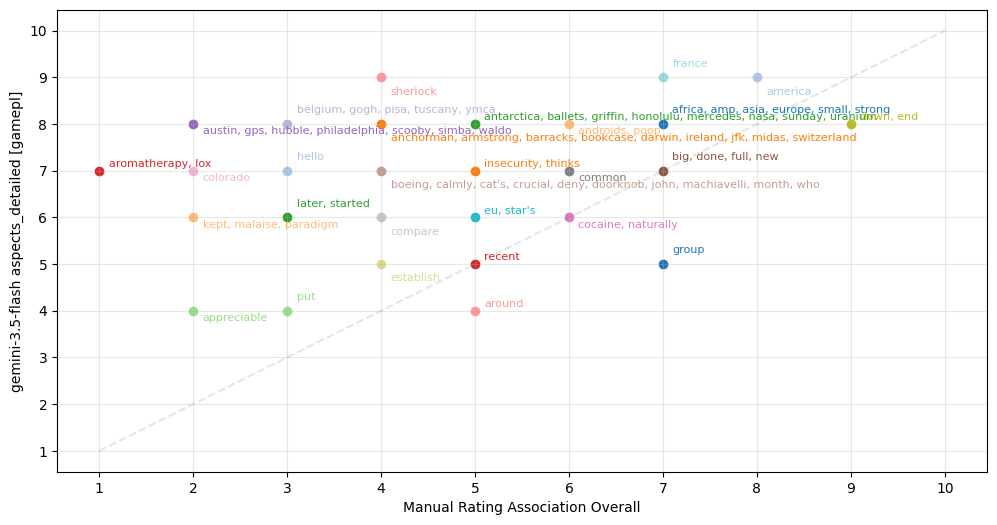

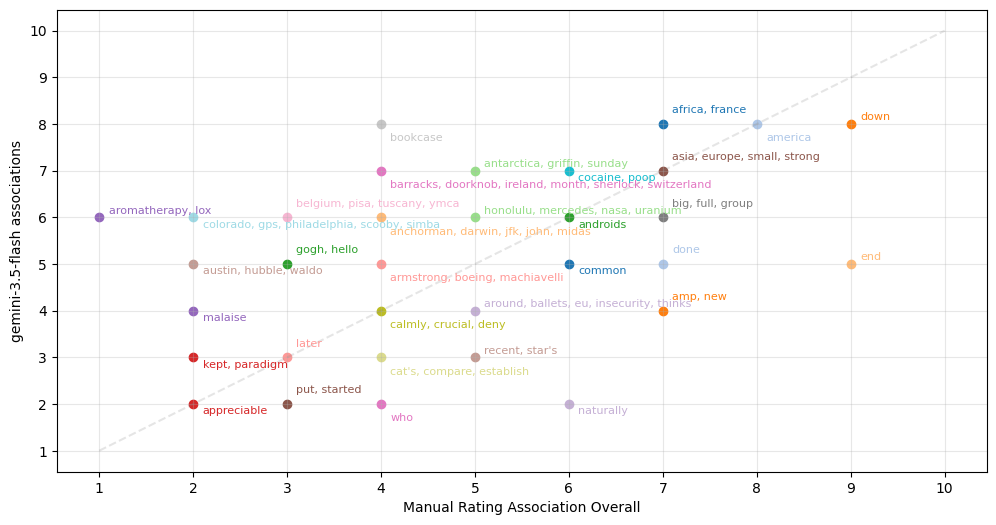

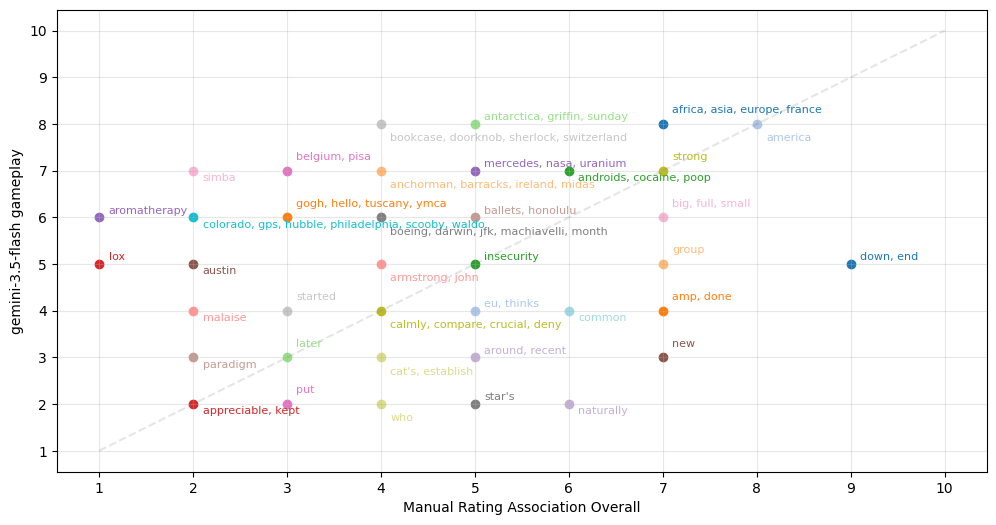

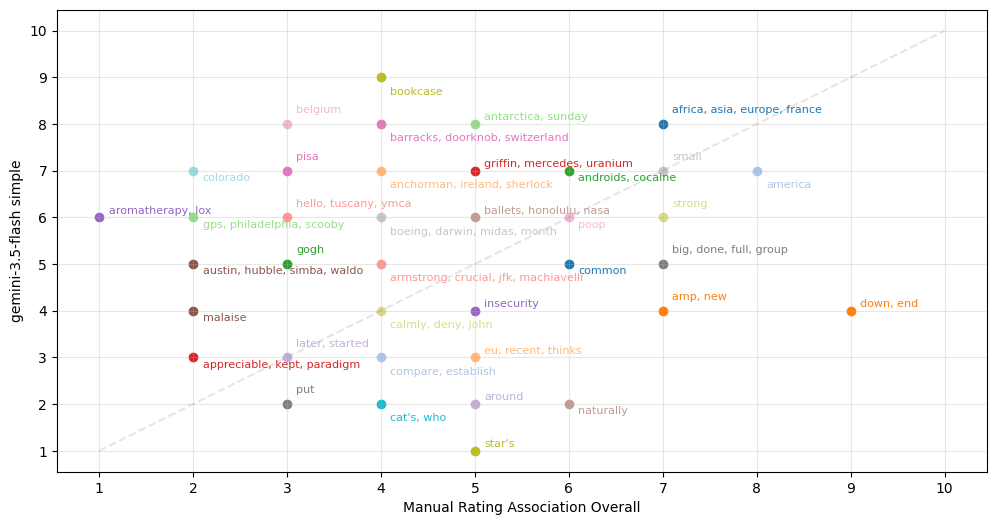

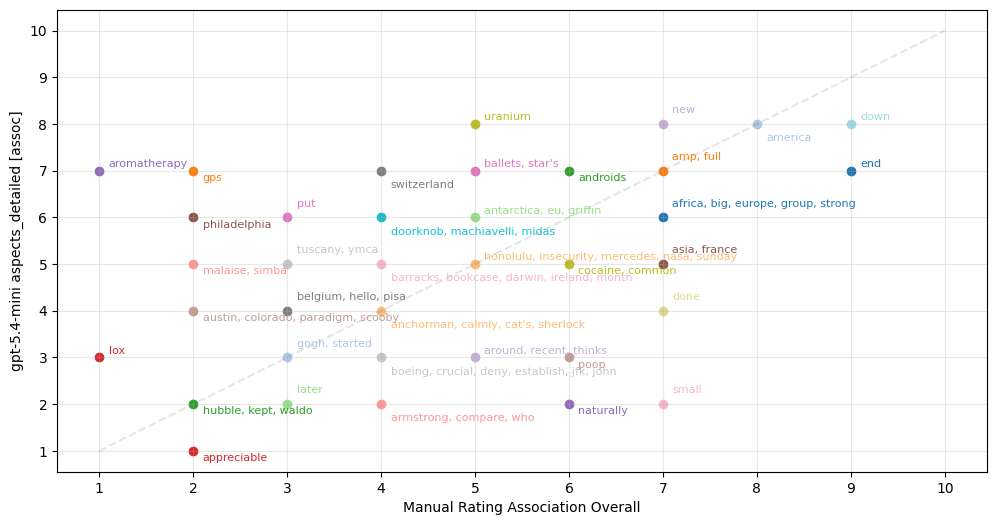

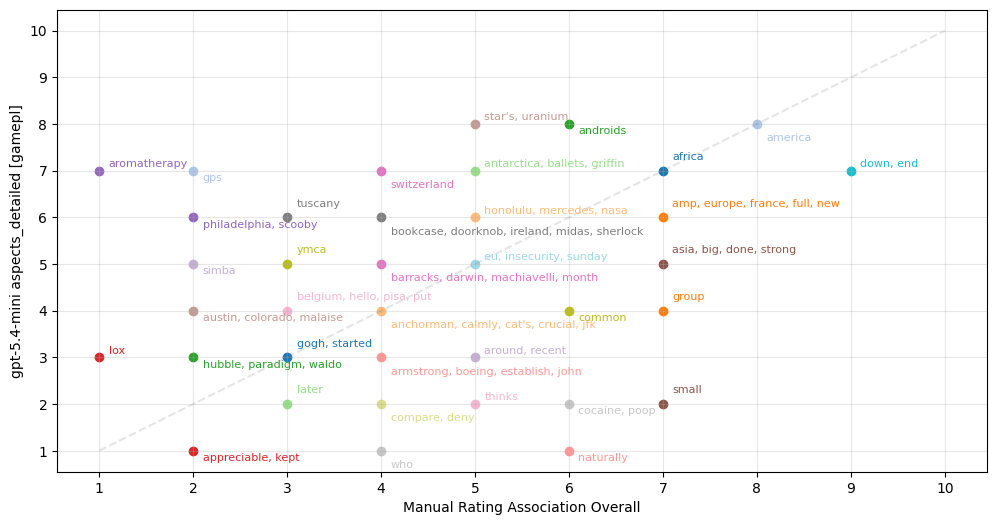

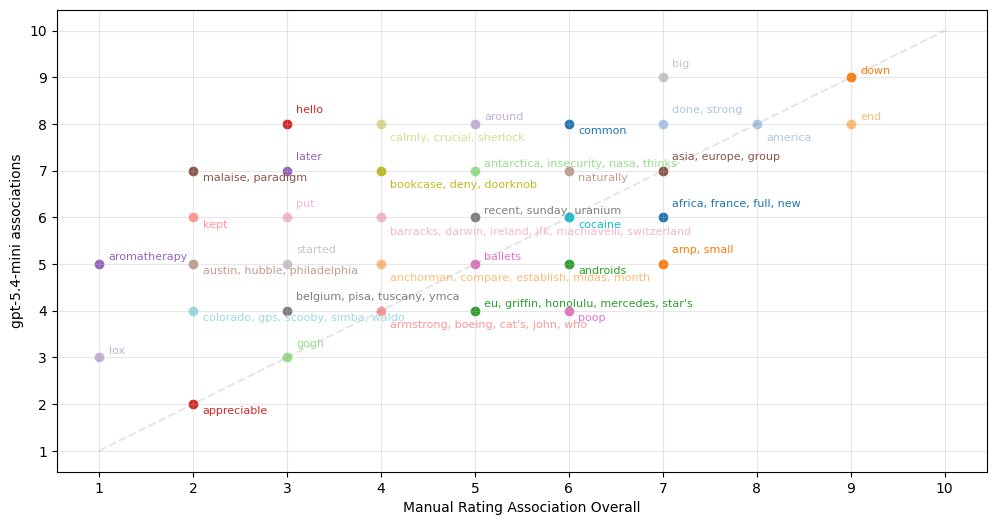

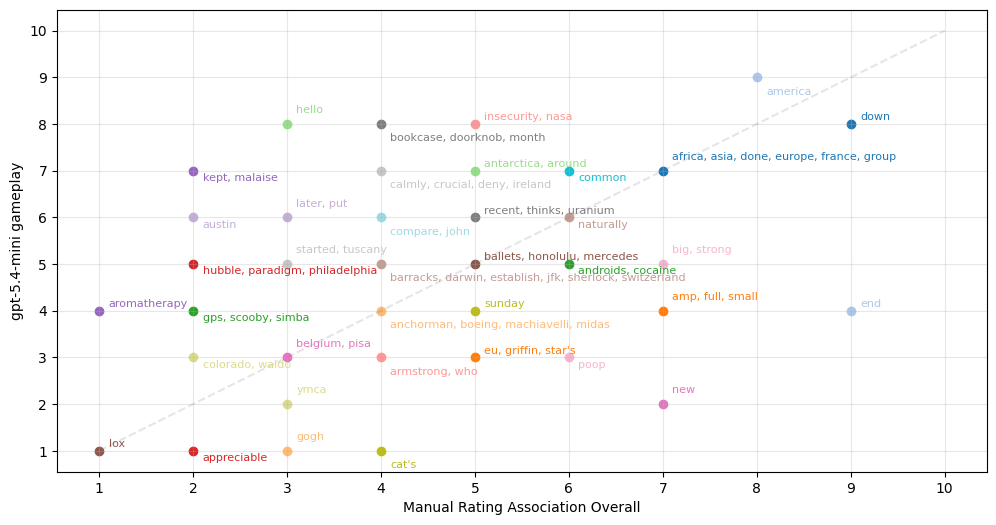

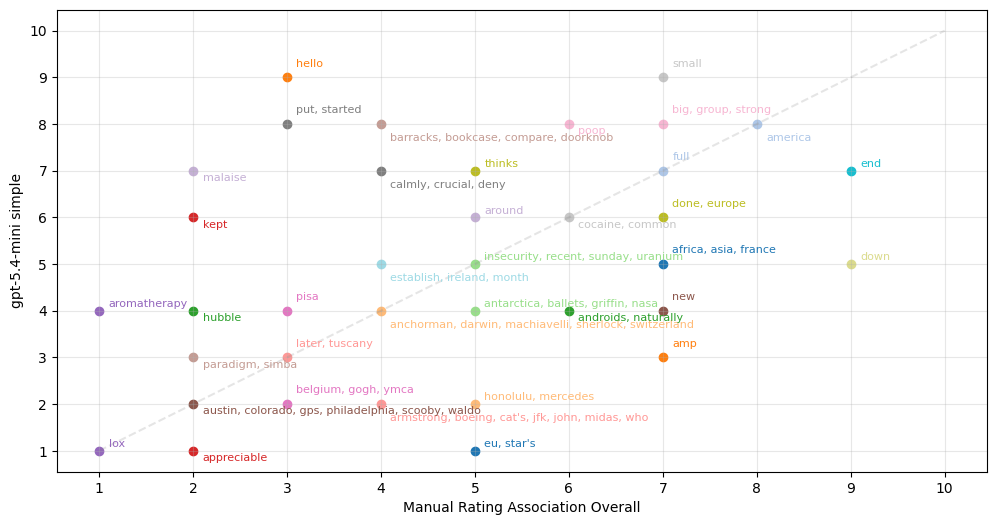

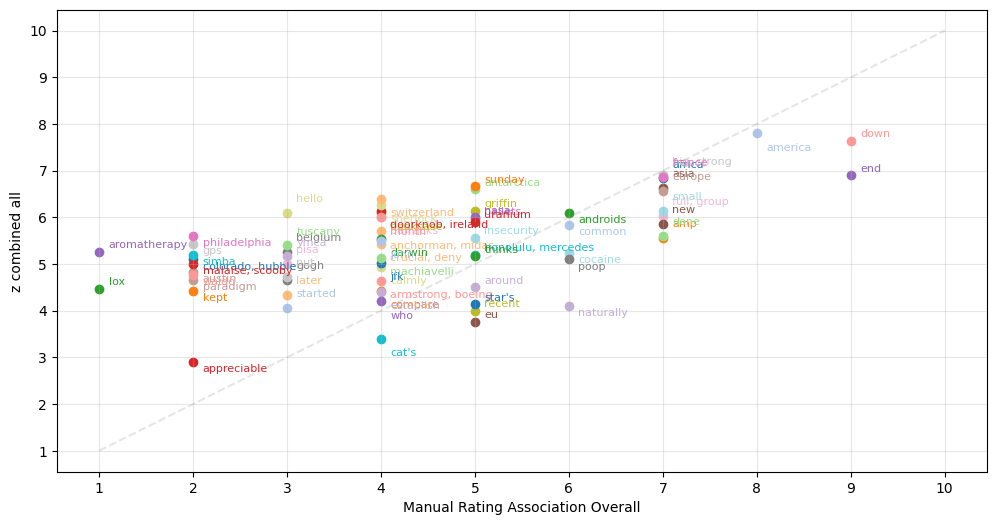

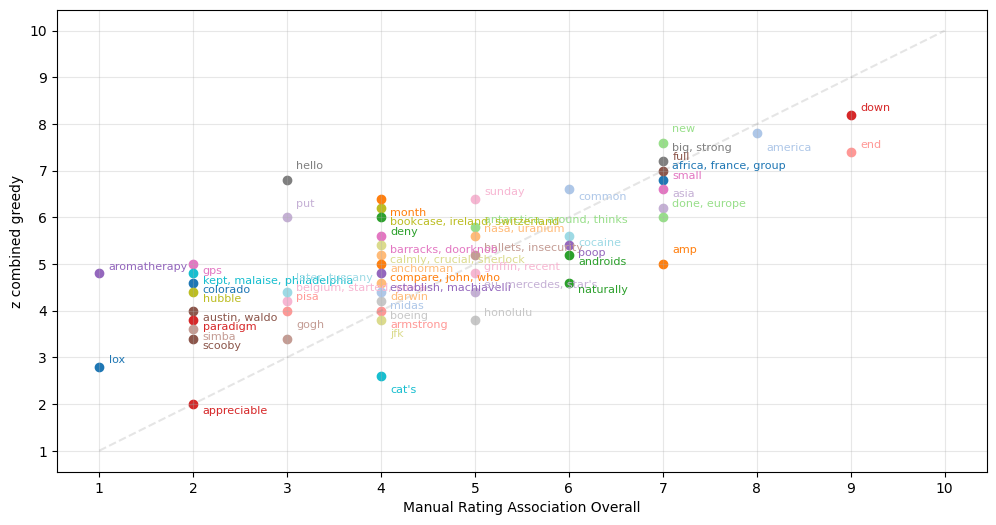

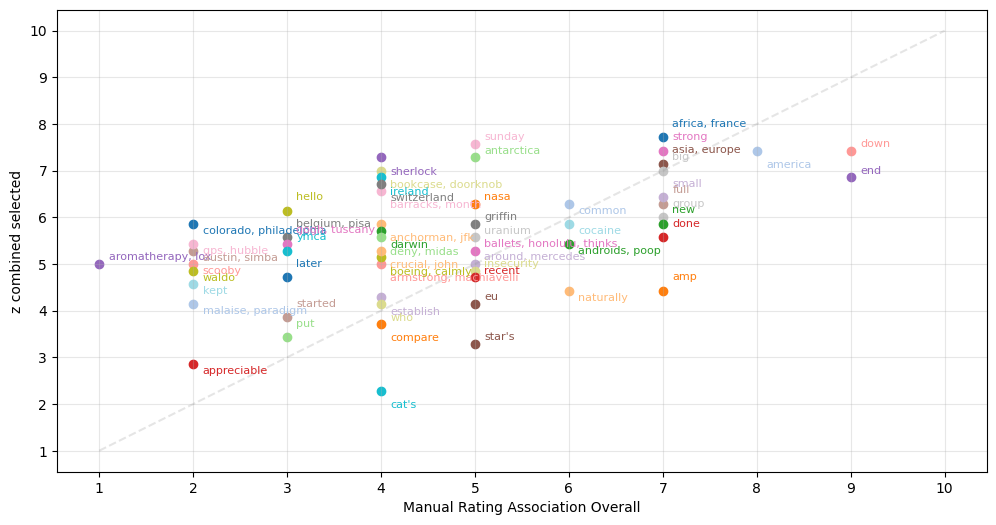

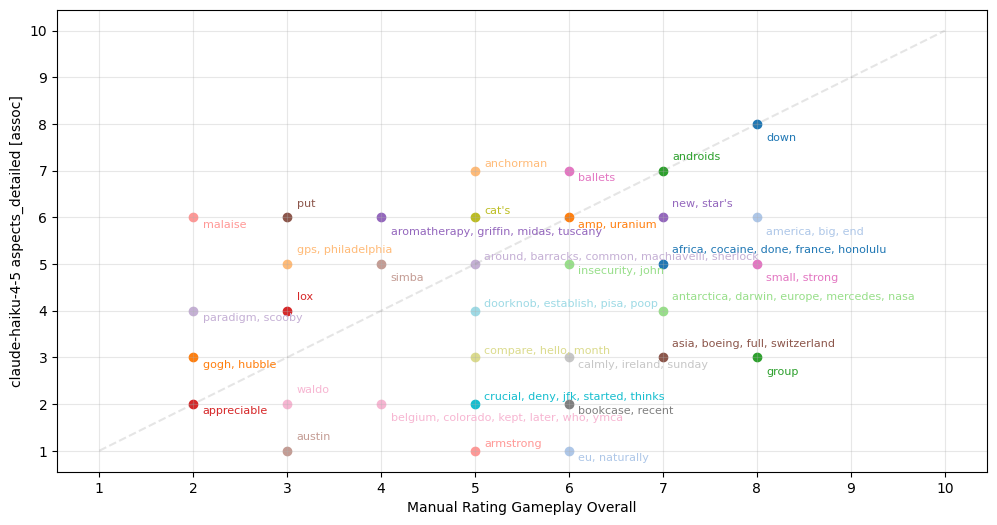

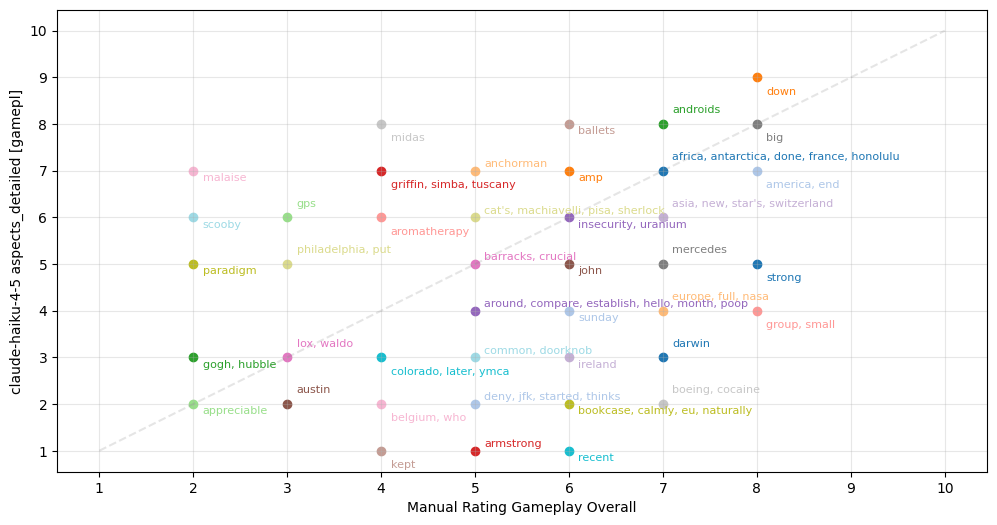

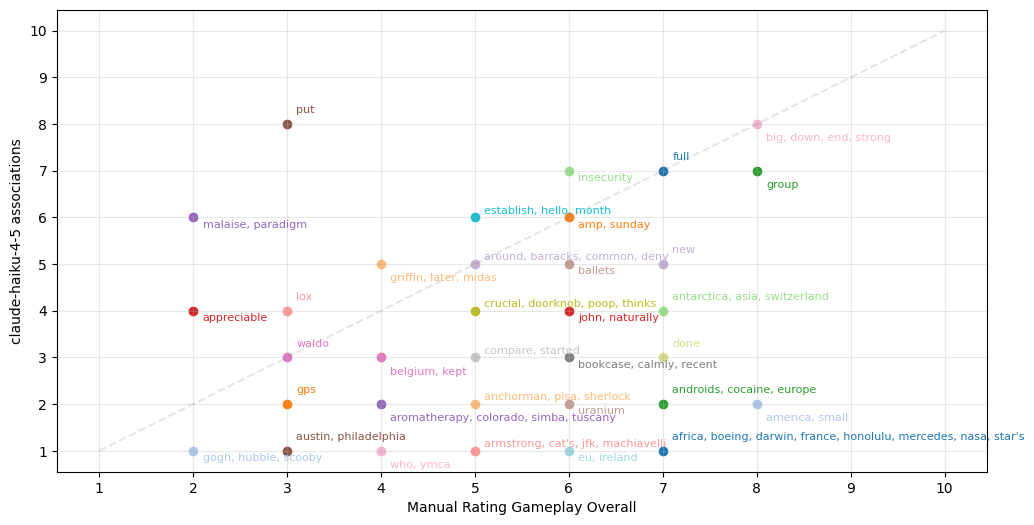

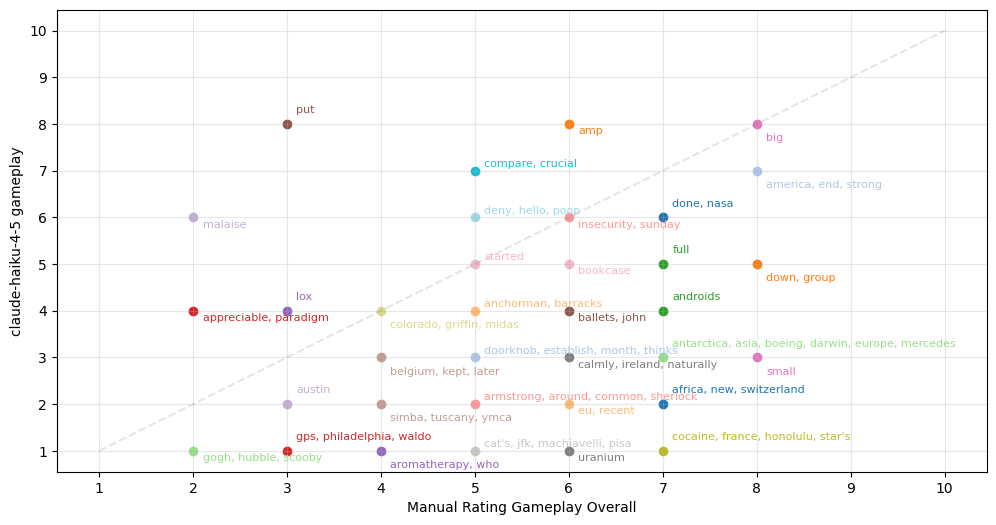

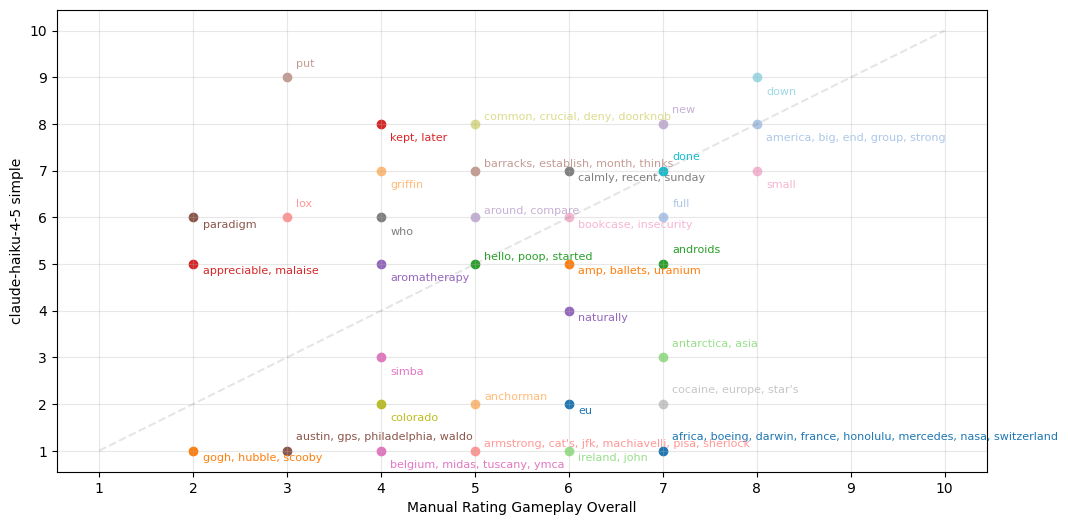

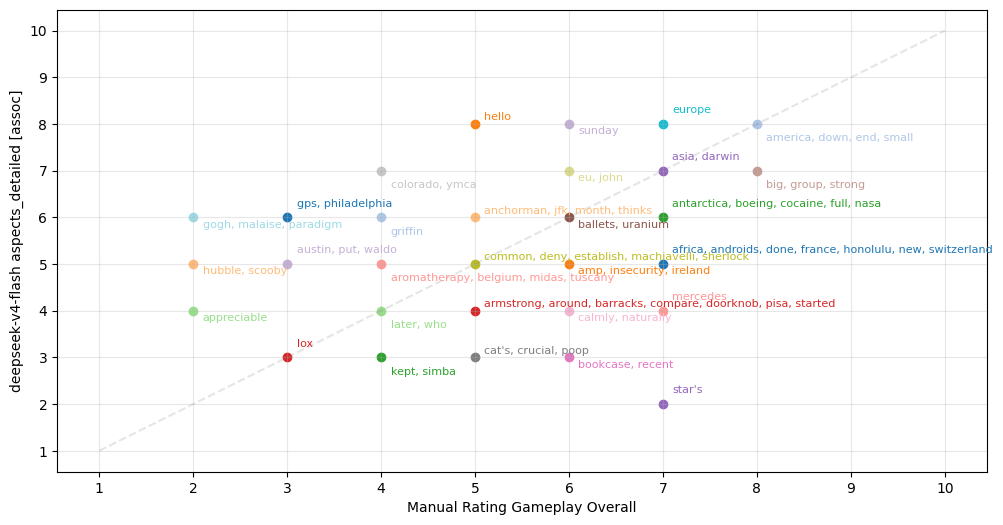

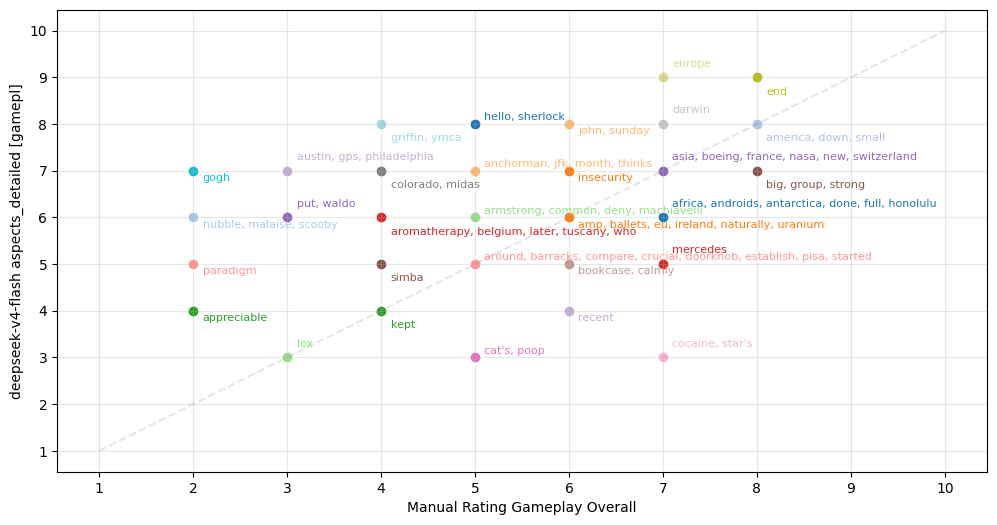

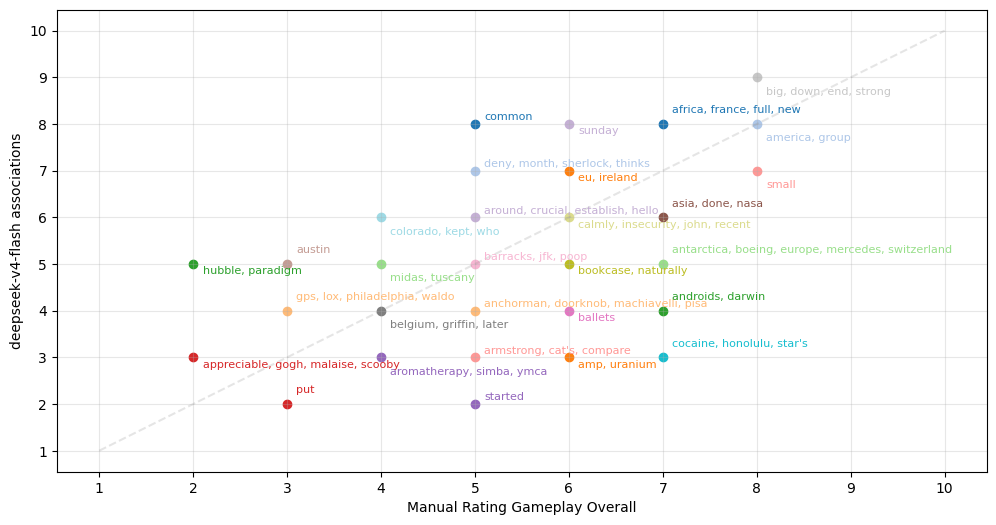

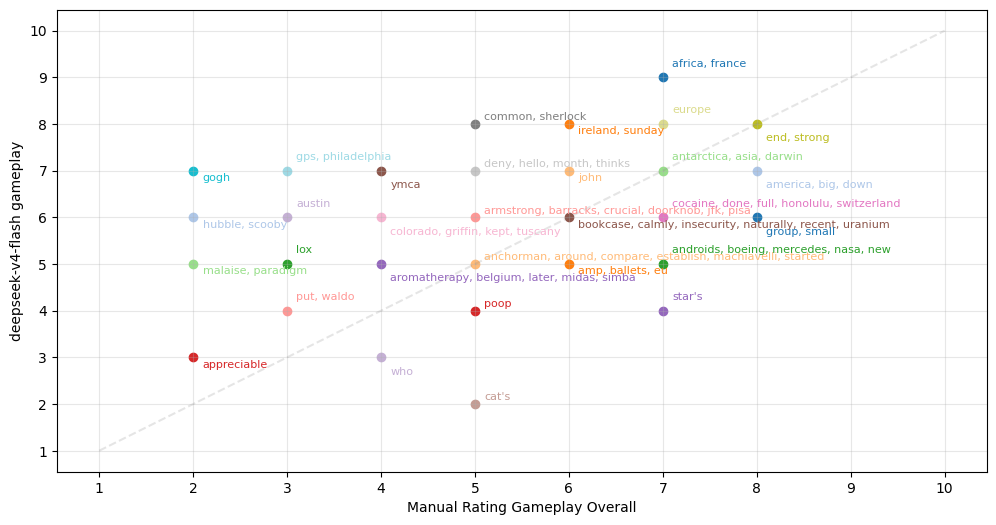

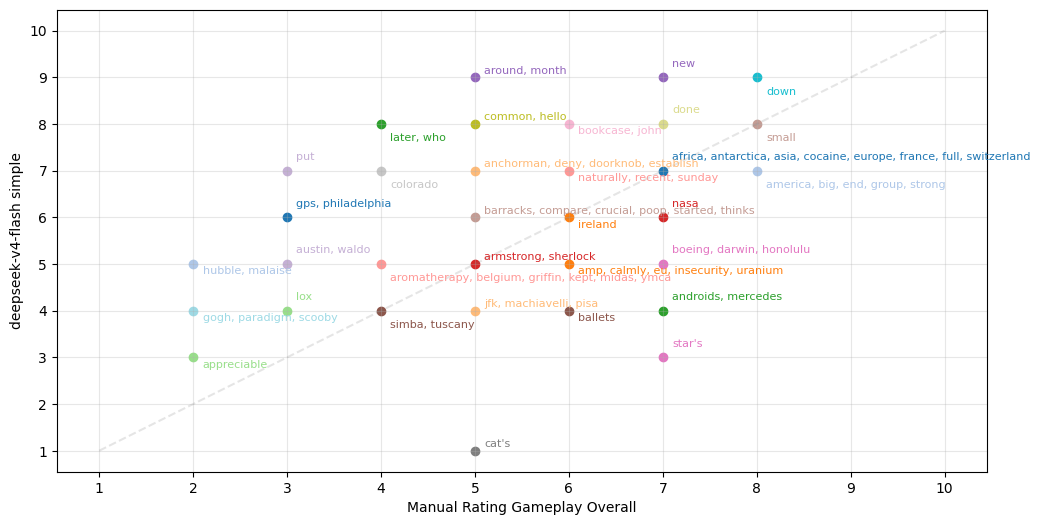

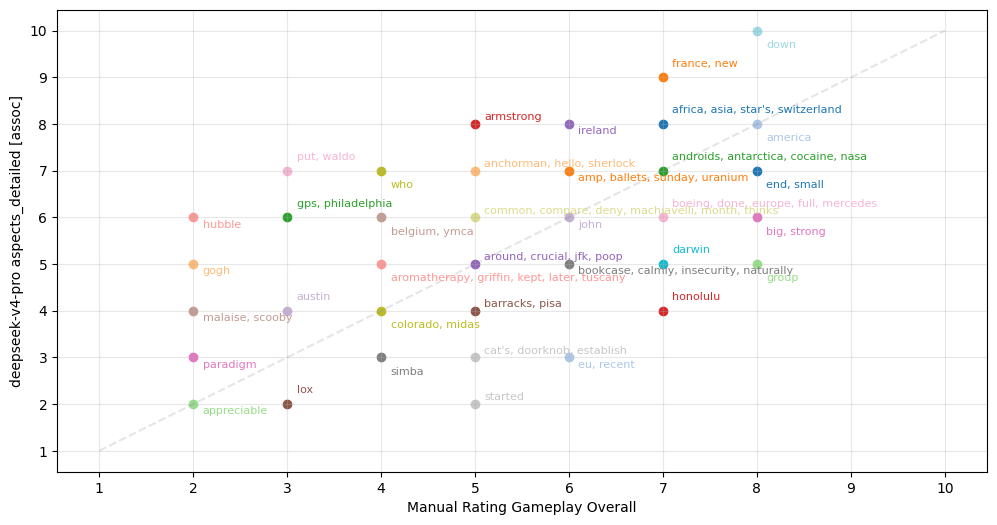

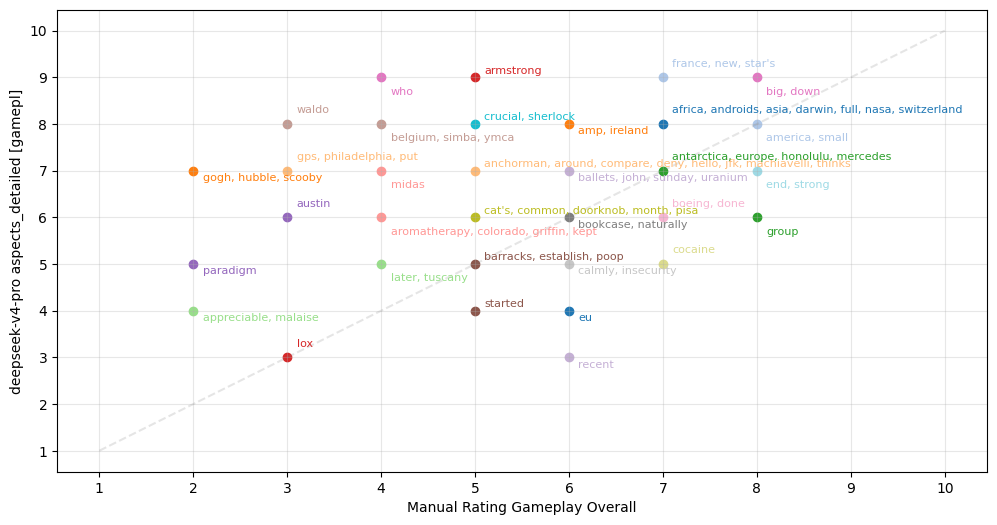

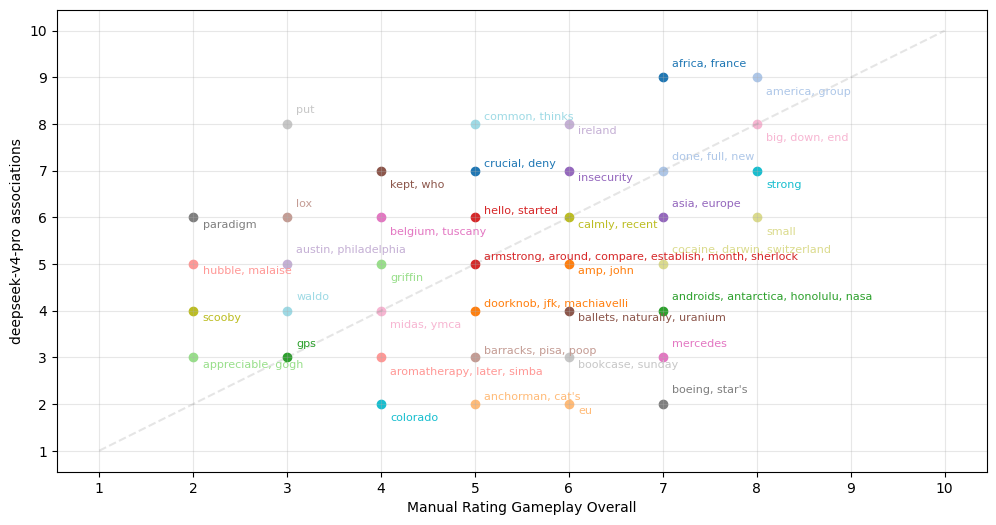

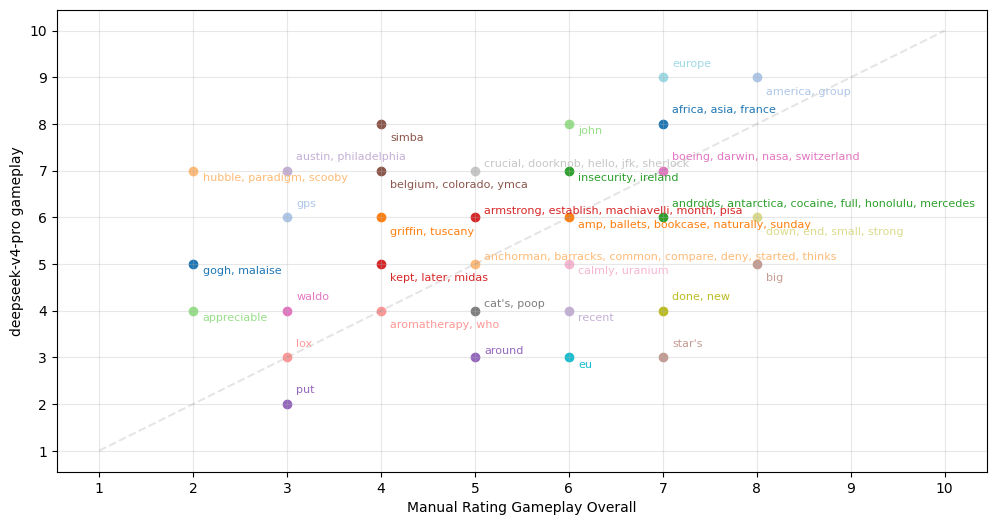

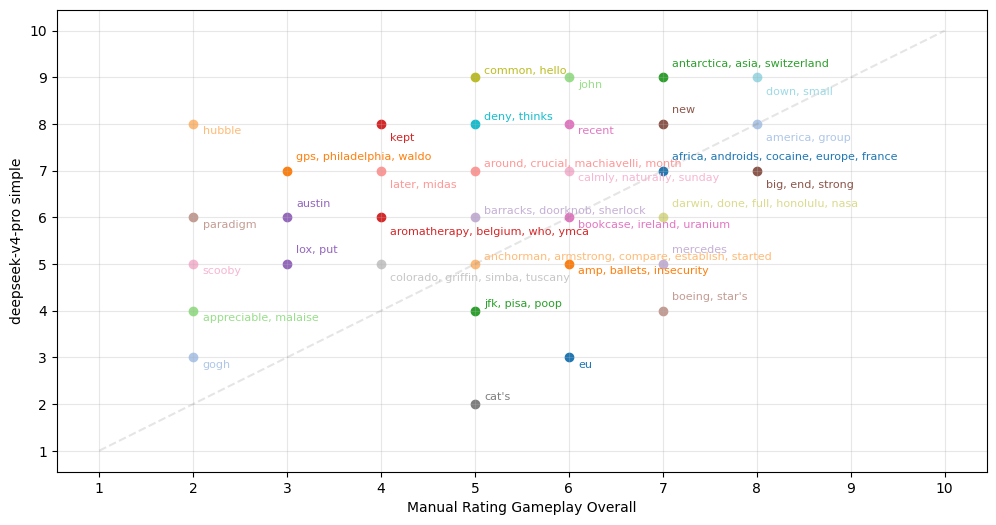

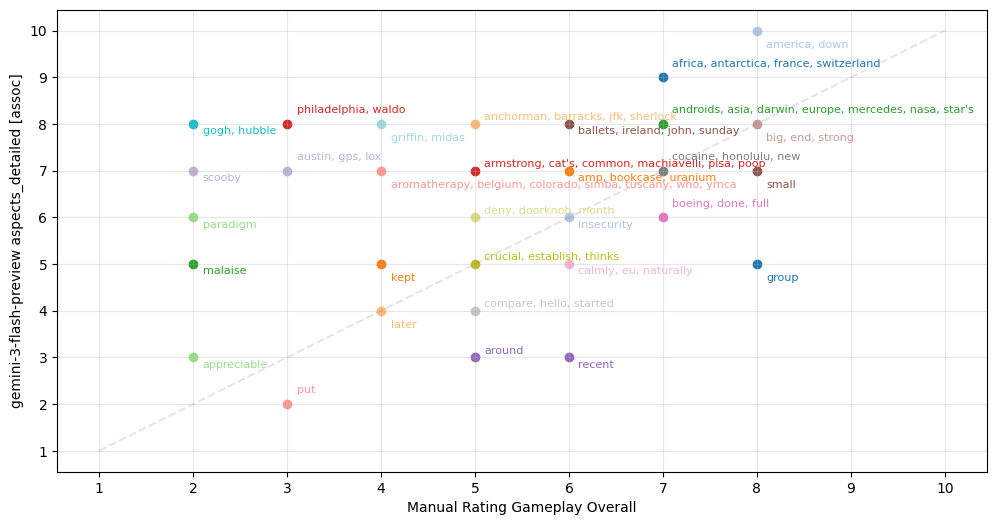

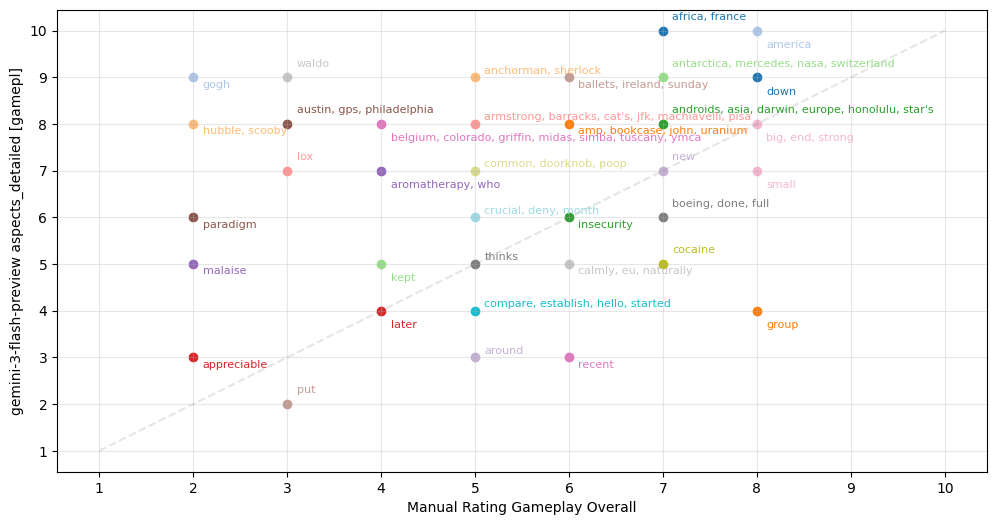

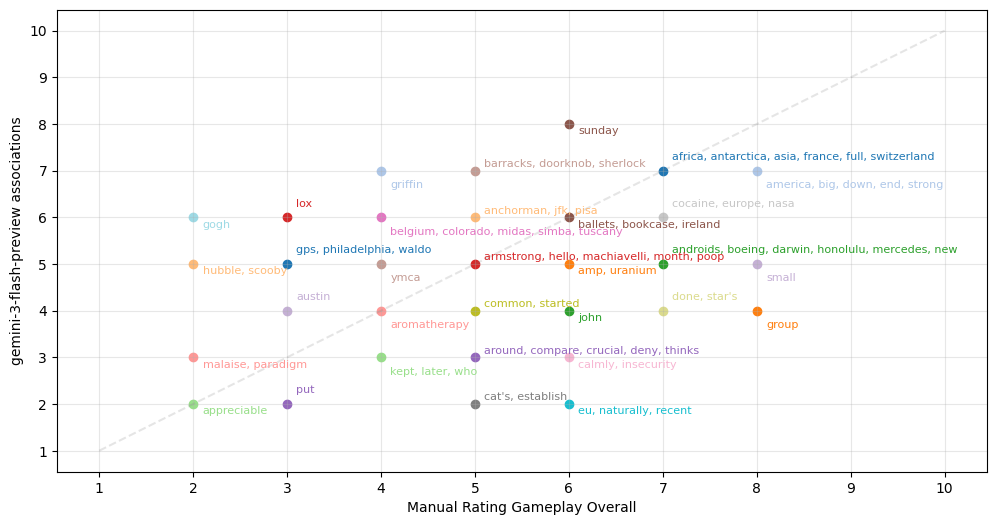

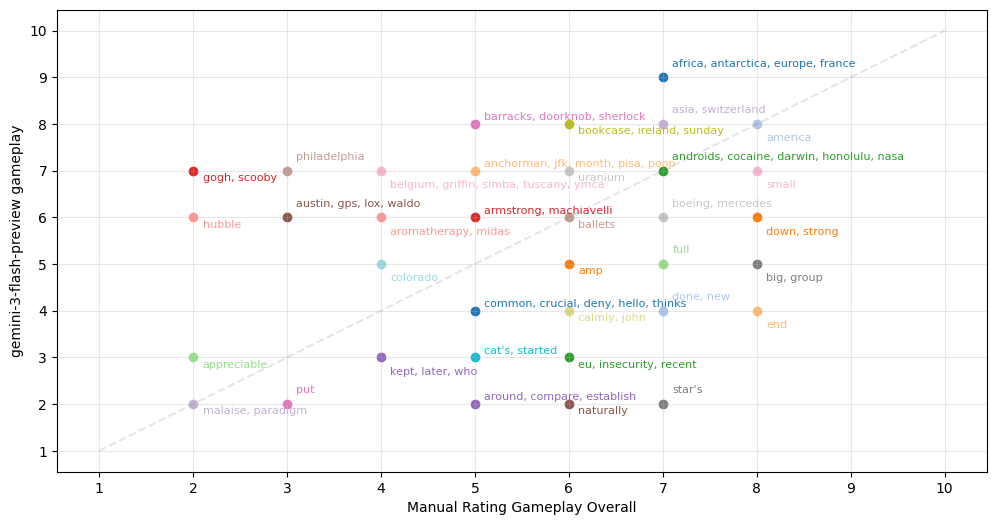

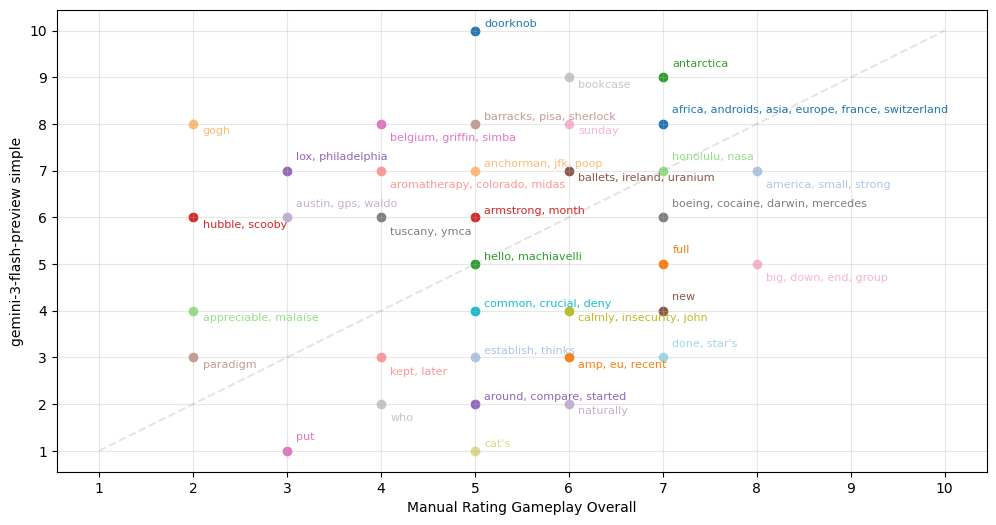

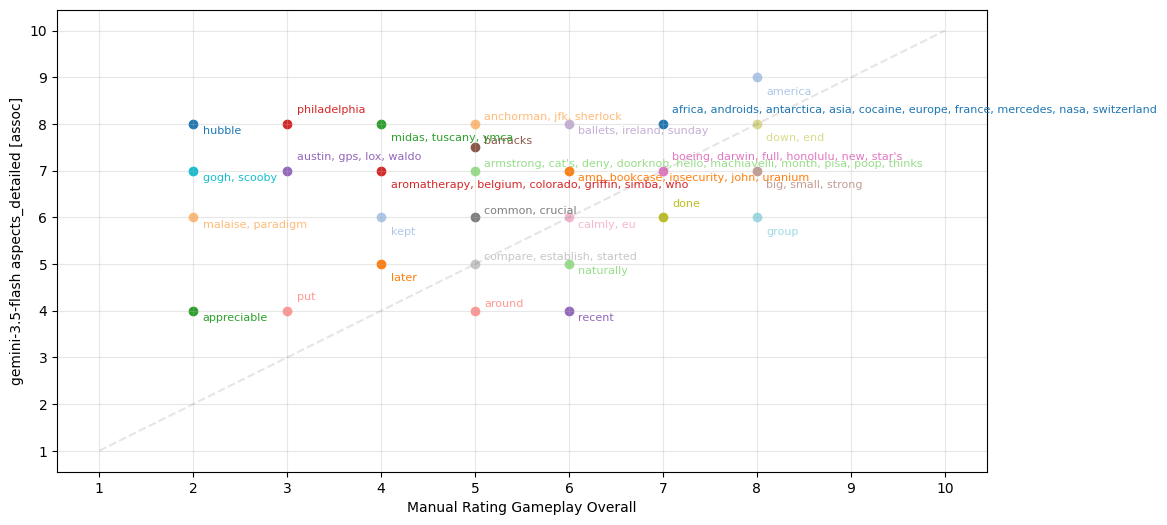

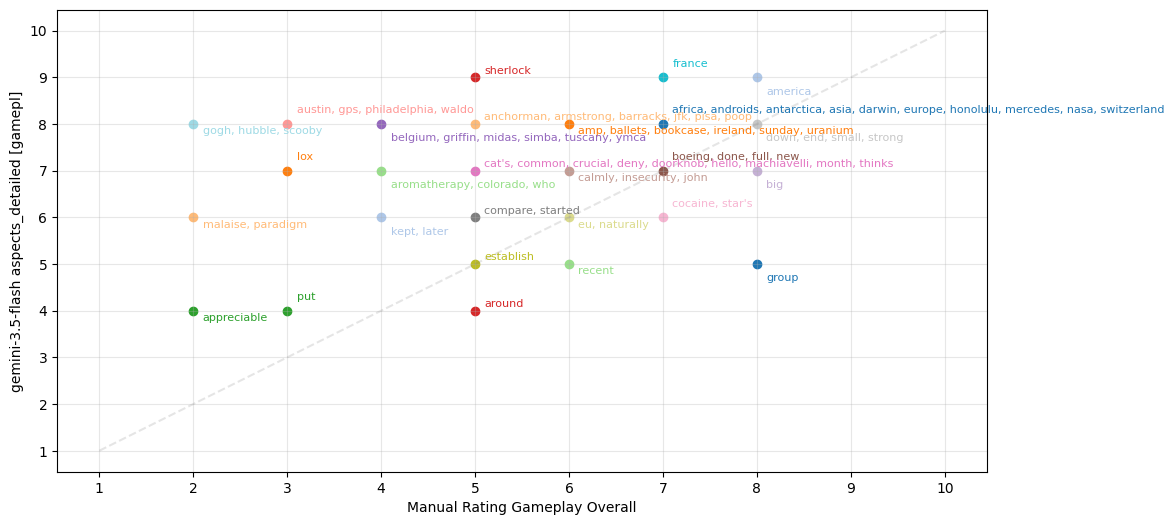

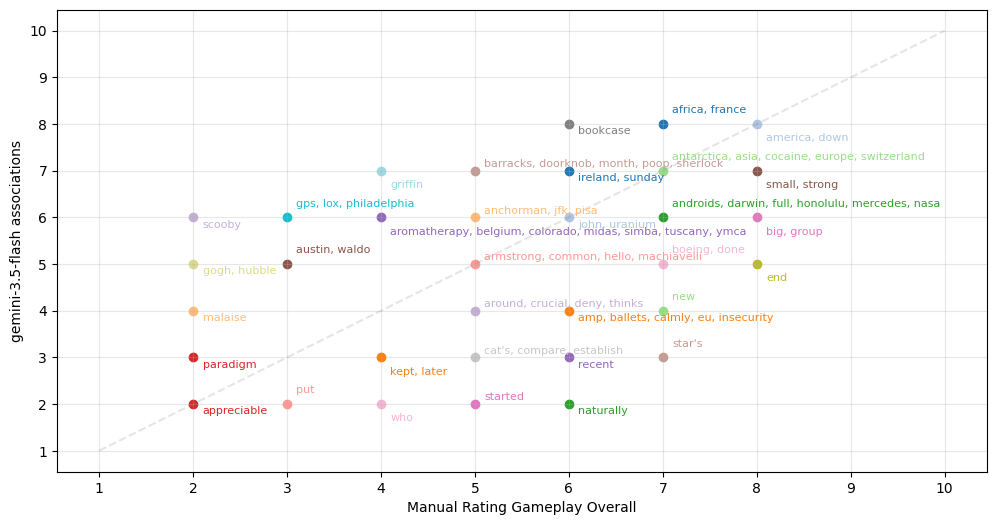

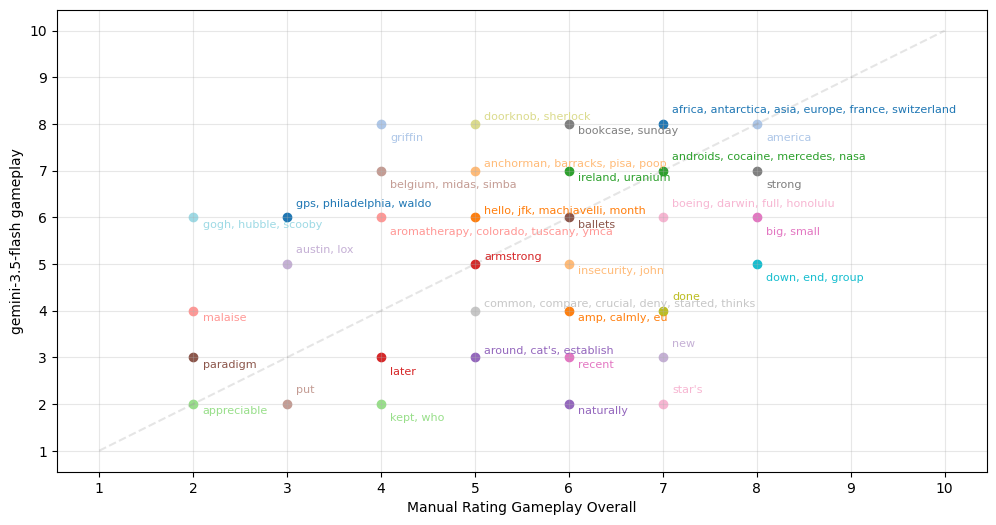

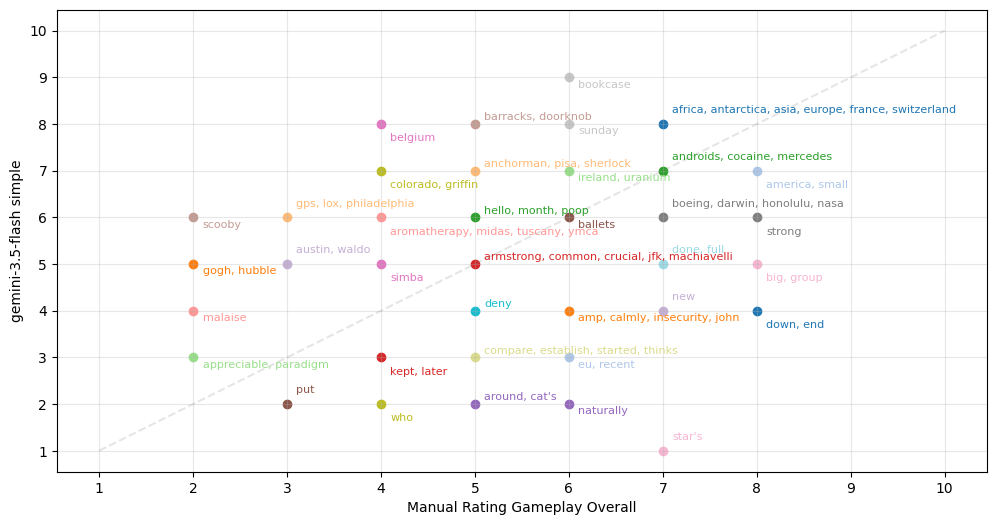

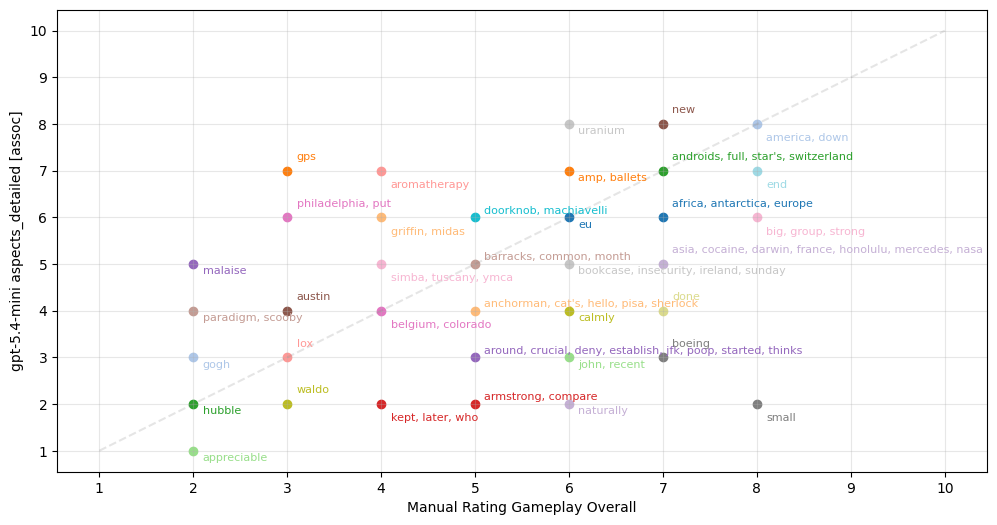

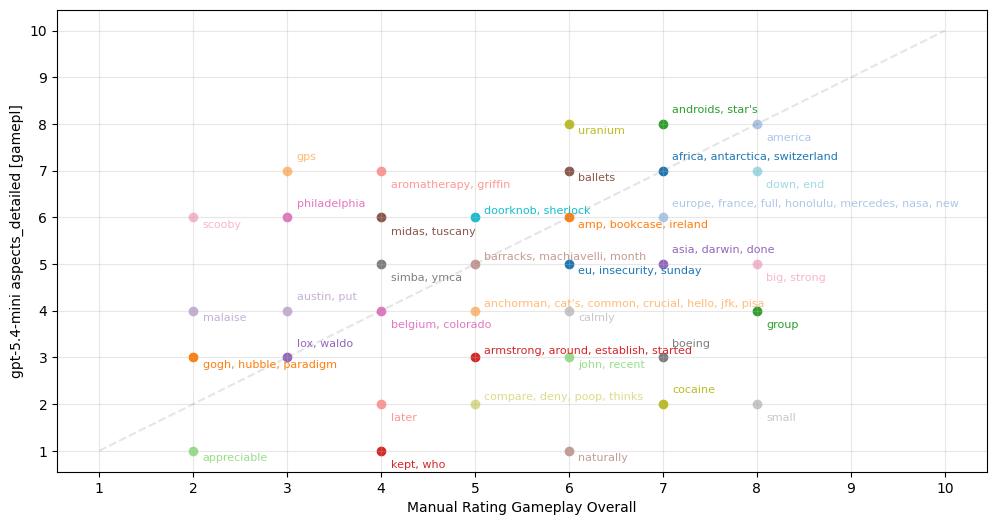

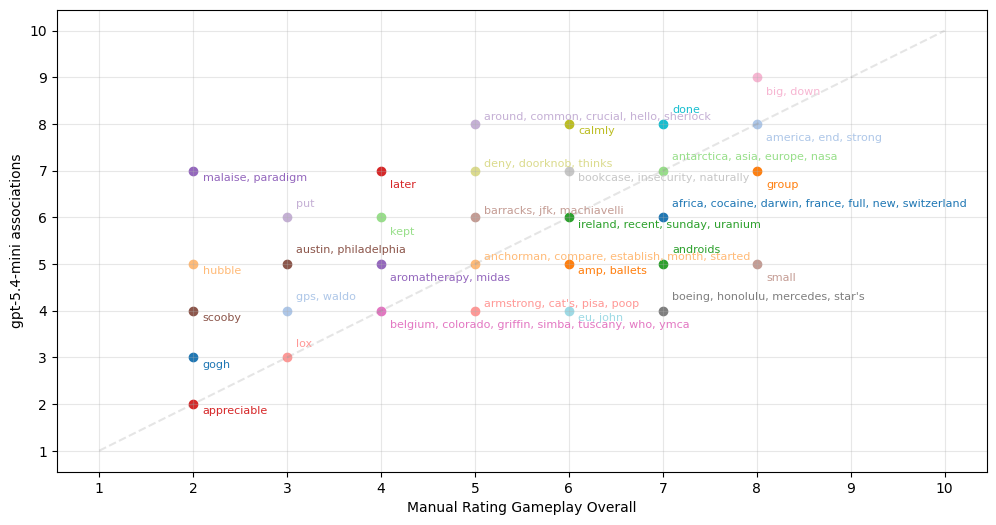

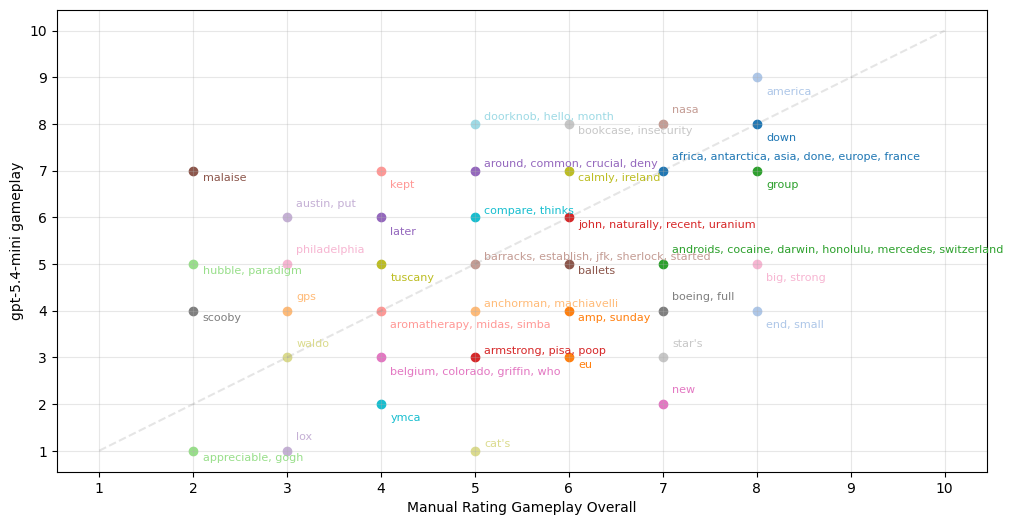

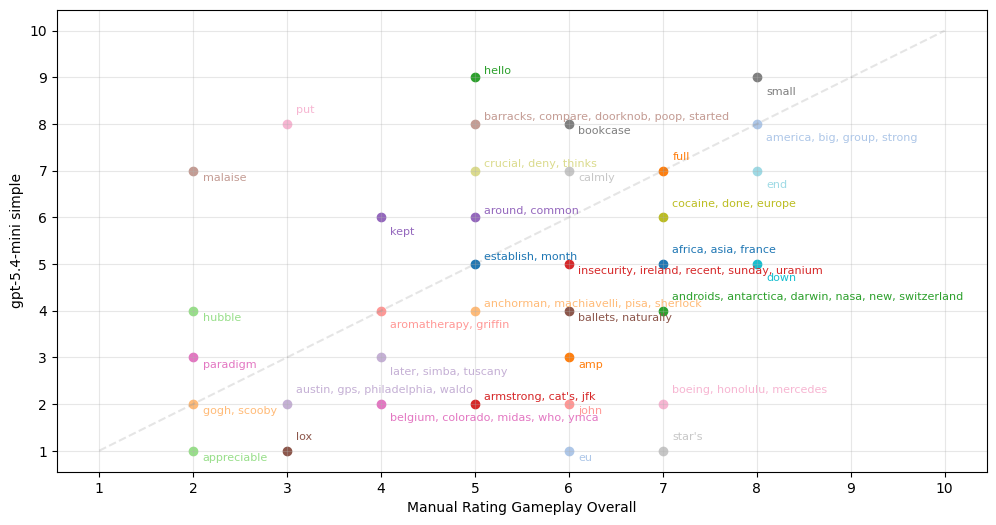

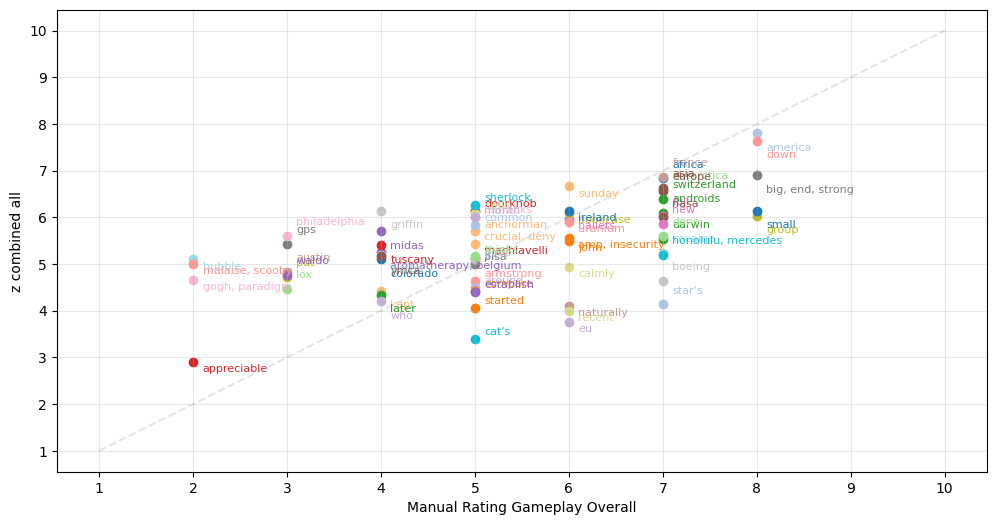

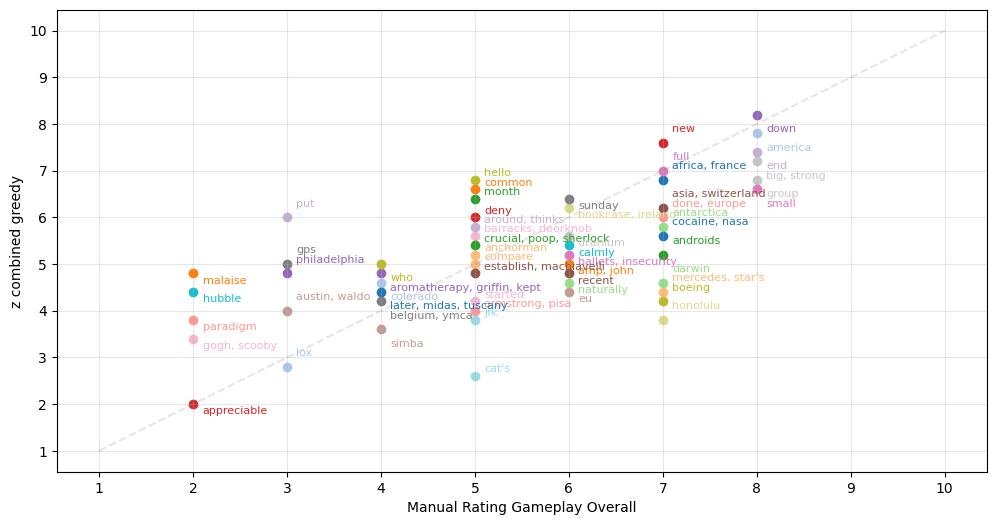

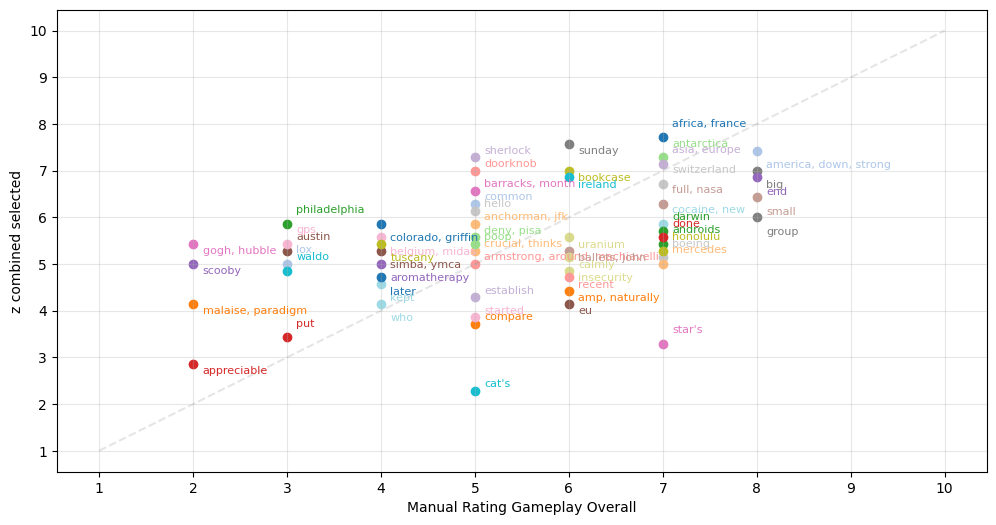

In [18]:
for target_field in fields_to_display:
    for variation_view in iter_variation_views(results_by_variation):
        words_by_coordinate = defaultdict(list)
        for word in manual_ratings_words:
            manual_rating = manual_ratings[word][target_field]
            model_rating = variation_view.overall_rating(word)
            words_by_coordinate[(manual_rating, model_rating)].append(word)

        plt.figure(figsize=(12, 6))
        cmap = plt.get_cmap("tab20")
        for i, (coordinate, words) in enumerate(words_by_coordinate.items()):
            color = cmap(i % cmap.N)
            manual_rating, model_rating = coordinate
            assert len(coordinate) > 0
            words_str = ", ".join(words)
            plt.scatter(
                manual_rating,
                model_rating,
                label=words_str,
                color=color,
            )
            x_offset = 0.1
            y_amt = 0.15
            y_offset = [-2, 1, -1, 2][int(manual_rating) % 4] * y_amt
            plt.text(
                manual_rating + x_offset,
                model_rating + y_offset,
                words_str,
                fontsize=8,
                ha="left",
                va="center",
                color=color,
            )
        plt.xticks(range(1, 11))
        plt.yticks(range(1, 11))
        plt.xlabel(f"Manual Rating {target_field}")
        plt.ylabel(f"{variation_view.short_str()}")
        plt.grid(True, alpha=0.3)
        plt.plot([1, 10], [1, 10], color="gray", alpha=0.2, linestyle="--")
        plt.show()

# Explore Aspects Ratings

Study the subfeatures of Association and Gameplay from the 'aspects' prompt.

In [19]:
manual_ratings_by_field = {}
for field in rating_fields:
    manual_ratings_by_field[field] = [manual_ratings[w][field] for w in manual_ratings_words]

rows = []
for rbv_params, rbv_result in results_by_variation.items():
    if not rbv_params.is_aspects:
        continue
    row = [rbv_params.short_str()]
    for field in rating_fields:
        model_ratings_for_field = [rbv_result.ratings_by_word[w][field] for w in manual_ratings_words]
        tau = kendalltau(manual_ratings_by_field[field], model_ratings_for_field).statistic
        row.append(tau)
    rows.append(row)

print(
    tabulate(
        rows,
        headers=["Variation"] + rating_fields,
        tablefmt="github",
        floatfmt=".2f",
    )
)

| Variation                               |   Association Semantic/Category |   Association Functional |   Association Multiple Meanings |   Association Metaphorical/Symbolic |   Association Idioms/Phrases |   Association Wordplay |   Association Visual |   Association Emotional |   Association Cultural/Historical |   Association Overall |   Gameplay Recognizability |   Gameplay Inoffensiveness |   Gameplay Evocativeness |   Gameplay Fun |   Gameplay Overall |
|-----------------------------------------|---------------------------------|--------------------------|---------------------------------|-------------------------------------|------------------------------|------------------------|----------------------|-------------------------|-----------------------------------|-----------------------|----------------------------|----------------------------|--------------------------|----------------|--------------------|
| gpt-5.4-mini aspects_detailed           |                           

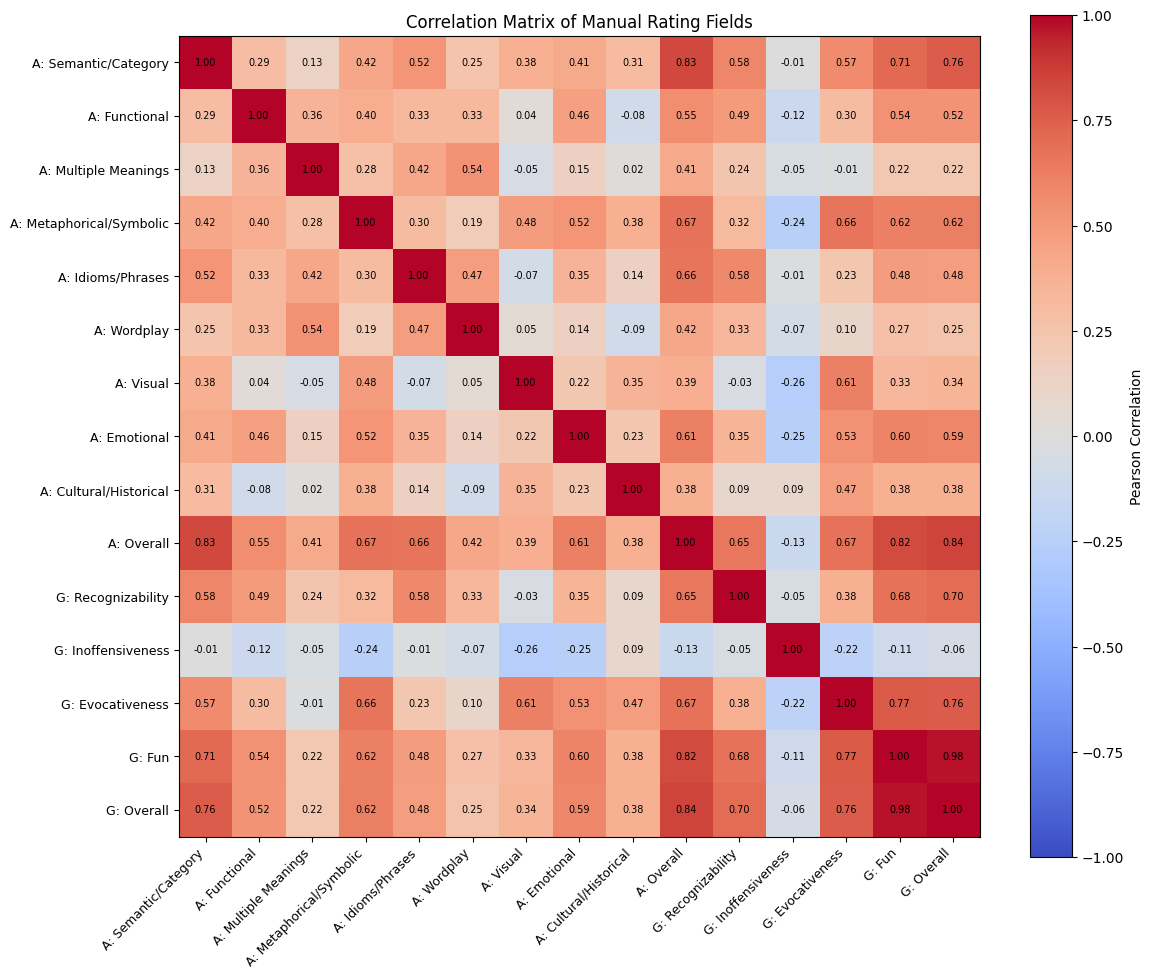

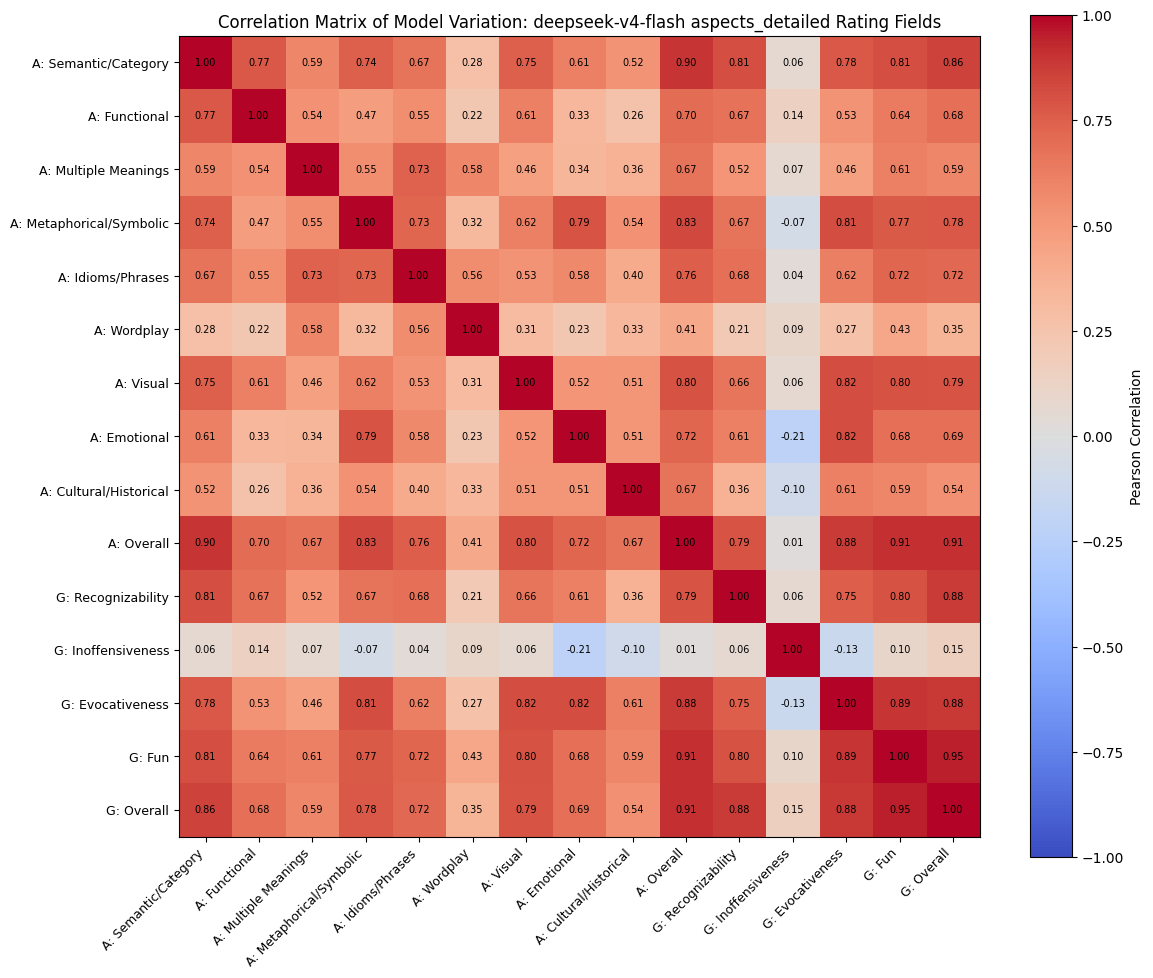

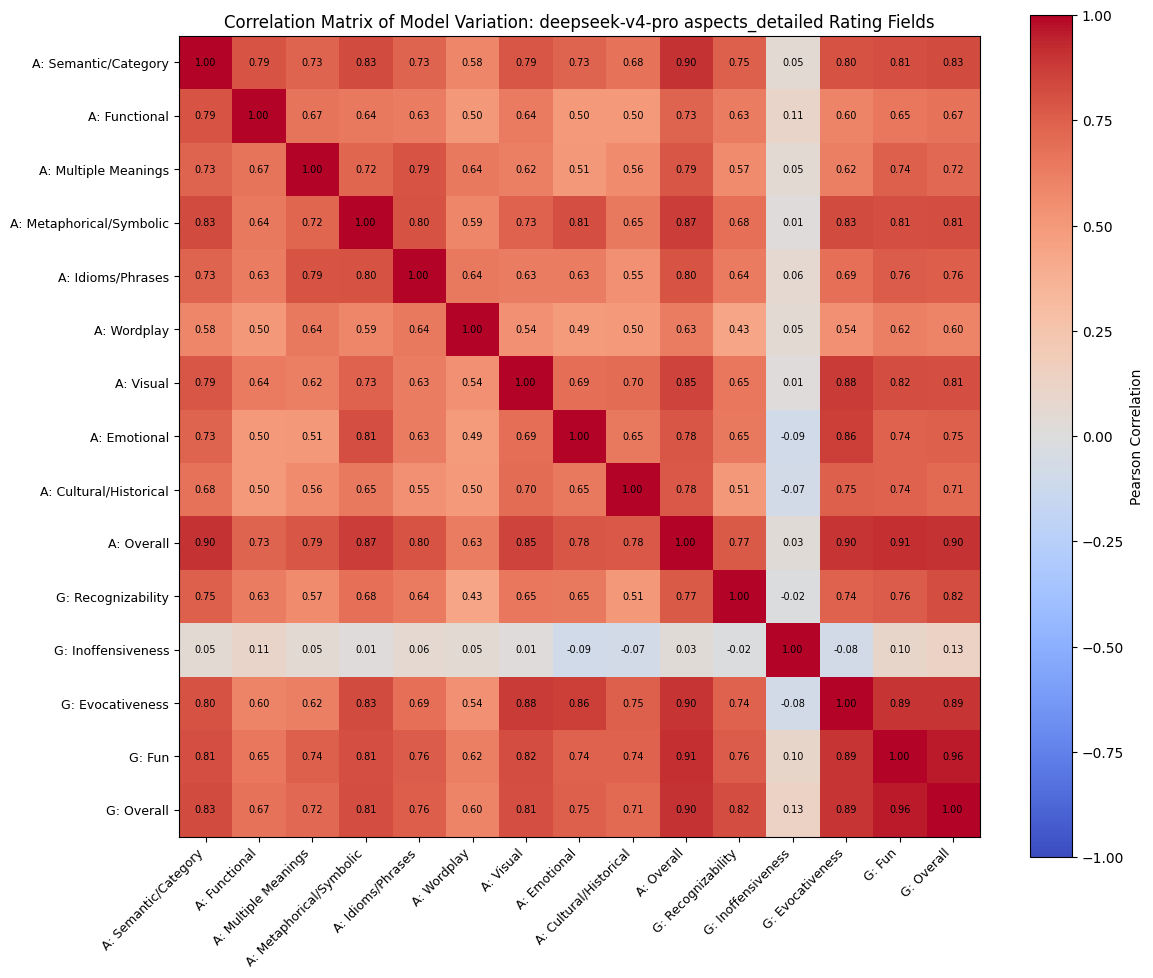

In [20]:
def show_ratings_correlation_matrix(ratings_by_word: RatingsByWord, ratings_title: str) -> None:
    rating_fields_count = len(rating_fields)
    ratings_words = sorted(ratings_by_word.keys())

    corr_matrix = [[0.0] * rating_fields_count for _ in range(rating_fields_count)]
    for i, field_a in enumerate(rating_fields):
        for j, field_b in enumerate(rating_fields):
            if i == j:
                corr_matrix[i][j] = 1.0
            else:
                ratings_a = [ratings_by_word[w][field_a] for w in ratings_words]
                ratings_b = [ratings_by_word[w][field_b] for w in ratings_words]
                corr_matrix[i][j] = correlation(ratings_a, ratings_b)

    short_fields = [f.replace("Association ", "A: ").replace("Gameplay ", "G: ") for f in rating_fields]

    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
    plt.colorbar(im, ax=ax, label="Pearson Correlation")
    ax.set_xticks(range(rating_fields_count))
    ax.set_yticks(range(rating_fields_count))
    ax.set_xticklabels(short_fields, rotation=45, ha="right", fontsize=9)
    ax.set_yticklabels(short_fields, fontsize=9)
    for i in range(rating_fields_count):
        for j in range(rating_fields_count):
            ax.text(j, i, f"{corr_matrix[i][j]:.2f}", ha="center", va="center", fontsize=7)
    ax.set_title(f"Correlation Matrix of {ratings_title} Rating Fields")
    fig.tight_layout()
    plt.show()

show_ratings_correlation_matrix(manual_ratings, "Manual")
variation_ratings_to_correlate = []
for rbv_params, rbv_result in results_by_variation.items():
    if rbv_params.prompt_name.startswith(
        "aspects_"
    ) and rbv_params.model_params.model.startswith("deepseek/"):
        variation_ratings_to_correlate.append((rbv_params.short_str(), rbv_result.ratings_by_word))
for variation_name, variation_ratings in variation_ratings_to_correlate:
    show_ratings_correlation_matrix(variation_ratings, f"Model Variation: {variation_name}")

In [21]:
target_fields = ["Association Overall", "Gameplay Overall"]

feature_sets = {
    "All non-overall fields": [f for f in rating_fields if f not in target_fields],
    "Association subratings only": [
        f
        for f in rating_fields
        if f.startswith("Association ") and f != "Association Overall"
    ],
    "Association subratings and Gameplay Overall": [
        f
        for f in rating_fields
        if (f.startswith("Association ") and f != "Association Overall") or f == "Gameplay Overall"
    ],
    "Gameplay subratings only": [
        f
        for f in rating_fields
        if f.startswith("Gameplay ") and f != "Gameplay Overall"
    ],
    "Gameplay subratings and Association Overall": [
        f
        for f in rating_fields
        if (f.startswith("Gameplay ") and f != "Gameplay Overall") or f == "Association Overall"
    ],
}

model_specs = {
    "OLS": make_pipeline(
        StandardScaler(),
        LinearRegression(),
    ),
    "RidgeCV": make_pipeline(
        StandardScaler(),
        RidgeCV(alphas=np.logspace(-3, 3, 25)),
    ),
    "LassoCV": make_pipeline(
        StandardScaler(),
        LassoCV(
            alphas=np.logspace(-3, 1, 25),
            max_iter=100_000,
            cv=5,
            random_state=0,
        ),
    ),
}


def standardize_y_model(model):
    return TransformedTargetRegressor(
        regressor=model,
        transformer=StandardScaler(),
    )


def get_final_estimator(fitted_model):
    # fitted_model is TransformedTargetRegressor
    pipeline = fitted_model.regressor_
    return pipeline[-1]


# Save particular coefficients for comparison with model results in later cells.
ridge_manual_coefficients_all_nonoverview_by_target_field = {}

for target_field in target_fields:
    y = np.array(
        [manual_ratings[w][target_field] for w in manual_ratings_words],
        dtype=float,
    )

    print(f"\n{'=' * 80}")
    print(f"Target: {target_field}")
    print(f"{'=' * 80}")

    for feature_set_name, feature_fields in feature_sets.items():
        if feature_set_name == "Association subratings and Gameplay Overall" and target_field == "Gameplay Overall":
            # This feature set would be circular for predicting Gameplay Overall, since it includes Gameplay Overall as a feature.
            continue
        if feature_set_name == "Gameplay subratings and Association Overall" and target_field == "Association Overall":
            # This feature set would be circular for predicting Association Overall, since it includes Association Overall as a feature.
            continue

        X = np.array(
            [
                [manual_ratings[w][f] for f in feature_fields]
                for w in manual_ratings_words
            ],
            dtype=float,
        )

        ss_tot = np.sum((y - y.mean()) ** 2)

        r2_rows = []
        coefs_by_model = {}

        for name, base_pipeline in model_specs.items():
            model = standardize_y_model(base_pipeline)

            fitted = clone(model).fit(X, y)
            r2_train = fitted.score(X, y)

            loo_preds = np.empty(len(y), dtype=float)

            for train_idx, test_idx in LeaveOneOut().split(X):
                fold_model = clone(model).fit(X[train_idx], y[train_idx])
                loo_preds[test_idx] = fold_model.predict(X[test_idx])

            r2_loo = 1 - np.sum((y - loo_preds) ** 2) / ss_tot

            final_estimator = get_final_estimator(fitted)
            alpha = getattr(final_estimator, "alpha_", "")

            r2_rows.append([name, r2_train, r2_loo, alpha])
            coefs_by_model[name] = final_estimator.coef_

            if name == "RidgeCV" and feature_set_name == "All non-overall fields":
                ridge_manual_coefficients_all_nonoverview_by_target_field[target_field] = (
                    final_estimator.coef_
                )

        print(
            f"\nFeature set: {feature_set_name}  (n={len(y)}, p={len(feature_fields)})"
        )
        print(
            tabulate(
                r2_rows,
                headers=["Model", "R² train", "R² LOO-CV", "Selected alpha"],
                tablefmt="github",
                floatfmt=".3f",
            )
        )

        print("")

        model_names = [name for name in model_specs]

        coef_rows = [
            [feature] + [coefs_by_model[name][i] for name in model_names]
            for i, feature in enumerate(feature_fields)
        ]

        # Sort by Ridge magnitude, because Ridge is usually more stable than OLS
        ridge_col_index = 1 + model_names.index("RidgeCV")
        coef_rows.sort(key=lambda row: abs(row[ridge_col_index]), reverse=True)

        print(
            tabulate(
                coef_rows,
                headers=["Feature"] + model_names,
                tablefmt="github",
                floatfmt=".3f",
            )
        )


Target: Association Overall

Feature set: All non-overall fields  (n=79, p=13)
| Model   |   R² train |   R² LOO-CV |   Selected alpha |
|---------|------------|-------------|------------------|
| OLS     |      0.946 |       0.922 |                  |
| RidgeCV |      0.944 |       0.923 |            5.623 |
| LassoCV |      0.946 |       0.924 |            0.003 |

| Feature                           |    OLS |   RidgeCV |   LassoCV |
|-----------------------------------|--------|-----------|-----------|
| Association Semantic/Category     |  0.446 |     0.383 |     0.445 |
| Association Idioms/Phrases        |  0.153 |     0.159 |     0.153 |
| Association Functional            |  0.157 |     0.137 |     0.155 |
| Association Metaphorical/Symbolic |  0.140 |     0.133 |     0.142 |
| Association Multiple Meanings     |  0.134 |     0.126 |     0.133 |
| Association Emotional             |  0.100 |     0.100 |     0.099 |
| Association Cultural/Historical   |  0.096 |     0.088 |   

In [22]:
variation_ratings_to_regress = []
for rbv_params, rbv_result in results_by_variation.items():
    if rbv_params.prompt_name.startswith("aspects_"):
        variation_ratings_to_regress.append(
            (rbv_params.short_str(), rbv_result.ratings_by_word)
        )

for target_field in target_fields:
    print(f"\n{'=' * 80}")
    print(f"Target: {target_field}")
    print(f"{'=' * 80}")

    feature_set_name = "All non-overall fields"
    feature_fields = feature_sets[feature_set_name]
    training_rows = [[variation_name[0]] for variation_name in variation_ratings_to_regress]
    coef_rows = [[feature_field] for feature_field in feature_fields]
    for i_feature, ridge_manual_coefficient in enumerate(ridge_manual_coefficients_all_nonoverview_by_target_field[target_field]):
        coef_rows[i_feature].append(ridge_manual_coefficient)
    for i_variation, (variation_name, variation_ratings) in enumerate(
        variation_ratings_to_regress
    ):
        y = np.array(
            [variation_ratings[w][target_field] for w in initial_words],
            dtype=float,
        )

        X = np.array(
            [[variation_ratings[w][f] for f in feature_fields] for w in initial_words],
            dtype=float,
        )

        model_name = "RidgeCV"
        base_pipeline = model_specs[model_name]
        model = standardize_y_model(base_pipeline)

        fitted = clone(model).fit(X, y)
        r2_train = fitted.score(X, y)
        final_estimator = get_final_estimator(fitted)
        alpha = getattr(final_estimator, "alpha_", "")
        training_rows[i_variation].extend([r2_train, alpha])

        coefs = final_estimator.coef_
        for i, feature in enumerate(feature_fields):
            coef_rows[i].append(coefs[i])

    print(
        tabulate(
            training_rows,
            headers=["Variation"] + ["R² train", "Selected alpha"],
            tablefmt="github",
            floatfmt=".3f",
        )
    )

    print()
    variation_names = [vn for vn, _ in variation_ratings_to_regress]
    print(
        tabulate(
            coef_rows,
            headers=["Feature", "Manually Rated"] + variation_names,
            tablefmt="github",
            floatfmt=".3f",
        )
    )


Target: Association Overall
| Variation                               |   R² train |   Selected alpha |
|-----------------------------------------|------------|------------------|
| gpt-5.4-mini aspects_detailed           |      0.947 |            3.162 |
| claude-haiku-4-5 aspects_detailed       |      0.960 |            5.623 |
| gemini-3-flash-preview aspects_detailed |      0.970 |            3.162 |
| gemini-3.5-flash aspects_detailed       |      0.962 |           10.000 |
| deepseek-v4-flash aspects_detailed      |      0.948 |            5.623 |
| deepseek-v4-pro aspects_detailed        |      0.943 |           17.783 |

| Feature                           |   Manually Rated |   gpt-5.4-mini aspects_detailed |   claude-haiku-4-5 aspects_detailed |   gemini-3-flash-preview aspects_detailed |   gemini-3.5-flash aspects_detailed |   deepseek-v4-flash aspects_detailed |   deepseek-v4-pro aspects_detailed |
|-----------------------------------|------------------|-------------------

# LLM Cache Size

In [23]:
final_cache_count = get_cache_count()
print(
    f"Cache count {final_cache_count}, new entries this run: {final_cache_count - initial_cache_count}"
)

Cache count 1372, new entries this run: 0


# PIP Audit

Security check for packages that need to be updated.

In [24]:
# !pip-audit
pip_audit_with_urls()
# TODO: There is currently a vulnerability GHSA-r7w7-9xr2-qq2r in langchain-openai.
# However, I cannot update to the latest version because the updated langchain-openai requires openai>=2.24 but the latest stable litellm hard-pins openai==2.24.0.

| Name             | ID                                                                | Aliases                                                                                                                                     | Version   | Fix Versions   | Description                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    |
|:-----------------|:------------------------------------------------------------------|:--------------------------------------------------------------------------------------------------------------------------------------------|:----------|:---------------|:-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| diskcache        | [CVE-2025-69872](https://www.cve.org/CVERecord?id=CVE-2025-69872) | [GHSA-w8v5-vhqr-4h9v](https://github.com/advisories/GHSA-w8v5-vhqr-4h9v)                                                                    | 5.6.3     |                | <span title="DiskCache (python-diskcache) through 5.6.3 uses Python pickle for serialization by default. An attacker with write access to the cache directory can achieve arbitrary code execution when a victim application reads from the cache.">DiskCache (python-diskcache) through 5.6.3 uses Python pickle for serialization ...</span>                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 |
| langchain-core   | [CVE-2026-44843](https://www.cve.org/CVERecord?id=CVE-2026-44843) | [GHSA-pjwx-r37v-7724](https://github.com/advisories/GHSA-pjwx-r37v-7724)                                                                    | 1.3.0     | 0.3.85, 1.3.3  | <span title="LangChain contains older runtime code paths that deserialize run inputs, run outputs, or other application-controlled payloads using overly broad object allowlists. These paths may call `load()` with `allowed_objects=&quot;all&quot;`. This does not enable arbitrary Python object deserialization, but it does allow any trusted LangChain-serializable object to be revived, which is broader than these runtime paths require. As a result, attacker-supplied LangChain serialized constructor dictionaries may cause trusted runtime paths to instantiate classes with untrusted constructor arguments.  Applications are exposed only when all of the following are true:  1. The application accepts untrusted structured input, such as JSON, from a user or network request. 2. The application does not validate or canonicalize that input into an inert schema before invoking LangChain. 3. Attacker-controlled nested dictionaries or lists are preserved in LangChain run inputs or outputs. 4. The application uses an affected API path that later deserializes that run data.  Known affected runtime surfaces include:  - `RunnableWithMessageHistory` - `astream_log()` - `astream_events(version=&quot;v1&quot;)`  Related unsafe deserialization patterns may also affect applications that explicitly load serialized LangChain prompt or runnable objects from untrusted sources, including shared prompt stores, Hub artifacts with model configuration, or other application-controlled serialization stores.  Applications that validate incoming requests against a fixed schema, such as coercing user input to a plain string or message-content field before invoking LangChain, are unlikely to expose this deserialization primitive.  This release also fixes a related secret-marker validation bypass in the serialization and deserialization layer (`_is_lc_secret`). That issue creates an additional path by which attacker-controlled constructor dictionaries can avoid escaping during `dumps()` -&gt; `loads()` round-trips and reach LangChain object revival logic.  ## Impact  An attacker who can submit untrusted structured input to an affected application, and have that structure preserved in LangChain run data, may be able to inject LangChain serialized constructor payloads such as:  ```json {   &quot;lc&quot;: 1,   &quot;type&quot;: &quot;constructor&quot;,   &quot;id&quot;: [&quot;langchain_core&quot;, &quot;messages&quot;, &quot;ai&quot;, &quot;AIMessage&quot;],   &quot;kwargs&quot;: {&quot;content&quot;: &quot;attacker-controlled content&quot;} } ```  If this payload reaches a broad `load()` call, LangChain may instantiate the referenced class instead of treating the payload as inert user data.  Realistic impacts include:  - Persistent chat-history poisoning when revived `AIMessage`, `HumanMessage`, or `SystemMessage` objects are stored by `RunnableWithMessageHistory`. - Prompt injection or behavior manipulation if attacker-controlled messages are later included in model context. - Instantiation of unexpected trusted LangChain objects with attacker-controlled constructor arguments. - Possible credential disclosure or server-side requests if a reachable object reads environment credentials, creates clients, or contacts attacker-controlled endpoints during initialization. - Additional prompt-template or runnable-configuration impacts in applications that separately load and execute untrusted serialized LangChain objects.  ## Remediation  LangChain will deprecate the affected APIs as part of this fix:  - `RunnableWithMessageHistory` - `astream_log()` - `astream_events(version=&quot;v1&quot;)`  These are older code paths that are no longer recommended for new applications. They were not previously marked as deprecated, but recent LangChain documentation has primarily directed users toward newer streaming and memory patterns, including the `stream` API. Applications should migrate to the currently recommended APIs rather than continue depending on these older surfaces.  Separately, LangChain will update `load()` and `loads()` to tighten deserialization behavior so broad object revival is not applied implicitly to untrusted or application-controlled payloads. The older runtime surfaces listed above are being deprecated rather than preserved as supported paths for broad runtime deserialization.  This release also fixes a related secret-marker validation bypass in the serialization and deserialization layer (`_is_lc_secret`). That issue creates an additional path by which attacker-controlled constructor dictionaries can avoid escaping during `dumps()` -&gt; `loads()` round-trips and reach LangChain object revival logic.  ## Guidance for `load()` and `loads()`  `load()` and `loads()` should be used only with trusted LangChain manifests or serialized objects from trusted storage. Do not pass user-controlled data to `load()` or `loads()`, and do not use them as general parsers for request bodies, tool inputs, chat messages, or other attacker-controlled data.  `load()` and `loads()` are beta APIs, and their behavior may change as LangChain narrows unsafe defaults. Future LangChain versions will require callers to be explicit about which objects may be revived. Users should pass a narrow `allowed_objects` value appropriate for the specific trusted manifest they are loading, rather than relying on broad defaults or `allowed_objects=&quot;all&quot;`, which permits the full trusted LangChain serialization allowlist.  ## Credits  The original issue was first reported by @u-ktdi.  Similar findings were reported by @dewankpant, @shrutilohani, @Moaaz-0x, @pucagit.  A related `_is_lc_secret` marker bypass affecting `dumps()` -&gt; `loads()` round-trips was reported by @yardenporat353 (and a similar report by @localhost-detect)">LangChain contains older runtime code paths that deserialize run inputs, run out...</span>                                                                                                                                         |
| langchain-openai | [PYSEC-2026-76](https://osv.dev/vulnerability/PYSEC-2026-76)      | [GHSA-r7w7-9xr2-qq2r](https://github.com/advisories/GHSA-r7w7-9xr2-qq2r), [CVE-2026-41488](https://www.cve.org/CVERecord?id=CVE-2026-41488) | 1.1.10    | 1.1.14         | <span title="LangChain is a framework for building agents and LLM-powered applications. Prior to 1.1.14, langchain-openai&#x27;s _url_to_size() helper (used by get_num_tokens_from_messages for image token counting) validated URLs for SSRF protection and then fetched them in a separate network operation with independent DNS resolution. This left a TOCTOU / DNS rebinding window: an attacker-controlled hostname could resolve to a public IP during validation and then to a private/localhost IP during the actual fetch.">LangChain is a framework for building agents and LLM-powered applications. Prior...</span>                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             |
| langsmith        | [CVE-2026-45134](https://www.cve.org/CVERecord?id=CVE-2026-45134) | [GHSA-3644-q5cj-c5c7](https://github.com/advisories/GHSA-3644-q5cj-c5c7)                                                                    | 0.7.32    | 0.8.0          | <span title="## Description  The LangSmith SDK&#x27;s prompt pull methods (`pull_prompt` / `pull_prompt_commit` in Python, `pullPrompt` / `pullPromptCommit` in JS/TS) fetch and deserialize prompt manifests from the LangSmith Hub. These manifests may contain serialized LangChain objects and model configuration that affect runtime behavior. When pulling a public prompt by `owner/name` identifier, the manifest content is controlled by an external party, but prior versions of the SDK did not distinguish this from pulling a prompt within the caller&#x27;s own organization.  Prompt manifests can intentionally configure a model with a custom base URL, default headers, model name, or other constructor arguments. These are supported features, but they also mean the prompt contents should be treated as executable configuration rather than plain text. A prompt can also include serialized LangChain `Runnable` or `PromptTemplate` objects with attacker-controlled constructor kwargs, or secret references that, if `secrets_from_env` is enabled, read environment variables at deserialization time. Applications are exposed when all of the following are true:  - The application calls `pull_prompt` or `pull_prompt_commit` (Python) or `pullPrompt` or `pullPromptCommit` (JS/TS) with a public `owner/name` prompt identifier. - The prompt was published or modified by an untrusted or compromised account. - The application uses the pulled prompt without independently validating its contents.  Applications that only pull prompts from their own organization (referenced by name only, without an `owner/` prefix) are not affected by the public prompt trust boundary issue described above. However, same-organization prompts carry their own risk. If an attacker gains write access to the organization (for example, through a leaked `LANGSMITH_API_KEY` or a compromised team member account), they can push a malicious prompt that is pulled and deserialized without any additional warning.  ## Impact  An attacker who publishes a malicious prompt to LangSmith Hub may be able to affect applications that pull that prompt by `owner/name`. If the prompt manifest reaches the SDK&#x27;s deserialization path, the SDK will instantiate the referenced LangChain objects with the attacker-supplied constructor arguments rather than treating the manifest as inert data.  Realistic impacts include:  - Server-side request forgery (SSRF), outbound request redirection, and interception of LLM traffic if a prompt manifest configures an LLM client with an attacker-controlled `base_url`, proxy, or equivalent endpoint-setting parameter. In typical deployments, redirected requests may include prompt contents, system prompts, retrieved context, model parameters, provider credentials, or other secrets and may disclose them to the attacker-controlled endpoint. - Prompt injection or behavior manipulation if a manifest embeds attacker-controlled system messages, prompt templates, or model parameters that alter the application&#x27;s behavior. - Additional deserialization risk when `include_model=True` is passed, because this expands the allowlist to partner integration classes. This is not the default, but it materially increases risk when pulling prompts from outside the caller&#x27;s organization.  ## Remediation  The LangSmith SDK now blocks pulling public prompts by `owner/name` by default. Callers must explicitly opt in by passing `dangerously_pull_public_prompt=True` (Python) or `dangerouslyPullPublicPrompt: true` (JS/TS) to acknowledge the trust boundary. This flag should only be set after reviewing and trusting the prompt contents, not merely the publishing account.  Upgrade to LangSmith SDK **Python &gt;= 0.8.0** or **JS/TS &gt;= 0.6.0**.  ### Guidance for prompt pull methods  The prompt pull methods (`pull_prompt` / `pull_prompt_commit` in Python, `pullPrompt` / `pullPromptCommit` in JS/TS) should be used only with trusted prompts. Do not pull public prompts by `owner/name` from untrusted or unreviewed sources without understanding that the manifest contents will be deserialized and may affect runtime behavior.  When pulling prompts that include model configuration (`include_model=True` in Python, `includeModel: true` in JS/TS), the deserialization allowlist expands to include partner integration classes. Because this mode is not the default and is often unnecessary for third-party prompts, prefer the default (`false`) when pulling prompts from sources outside your organization.  Avoid passing `secrets_from_env=True` (Python) when pulling untrusted prompts. This parameter allows prompt manifests to read environment variables during deserialization. Only use it with trusted prompts from your own organization.  ### Same-organization prompts  Prompts pulled from the caller&#x27;s own organization (referenced by name only, without an `owner/` prefix) are not gated by the new `dangerously_pull_public_prompt` flag, but they are not inherently safe. If an attacker gains write access to the organization (for example, through a leaked `LANGSMITH_API_KEY` or a compromised team member account), they can push a malicious prompt that redirects LLM traffic to attacker-controlled infrastructure and may disclose any credentials attached to those requests.  The security of same-organization prompts follows a shared responsibility model. The LangSmith SDK enforces trust boundaries for public prompts pulled from external accounts, but it cannot protect against compromised credentials or accounts within the caller&#x27;s own organization. Securing API keys, managing team member access, and reviewing prompt contents before production deployment are the responsibility of the organization. Organizations should treat prompts as executable configuration and apply the same review and audit practices they would apply to application code.  ## Credits  First reported by @Moaaz-0x.">## Description  The LangSmith SDK&#x27;s prompt pull methods (`pull_prompt` / `pull_p...</span> |